## Cleaning 2021 Citation Files
- Input:
  - Civil Citation Data Entry Bagley_2025.02.23.csv
  - Civil Citation Data Entry Template AG 2025.02.27.csv
  - Civil Citation Data Entry Template Johnson_2025.01.30.csv
  - Civil Citation Data Entry Template_Baugh_2025.03.07.csv
  - Civil Citation Data Entry Template_Pozo_2025.03.08.csv
  - Civil Citation Data Entry Template JWM_03.20.25.csv
  - 2021_Civil_Summons_Sept.csv


- First Output: draft_2021_clean.csv 3/21/2025
- Second Output: clean_2021.csv 4/3/2025 --> final_clean_2021


---



**Data Cleaning Framework:**
1. Column-Matching (17) & Drop Duplicate Header  
2. Main Computer-Generated Validity Check
  - Through each section, there is a (hidden) computer-generated validity check for quality control
3. Replacing Empty Rows (NaN)s with "."
4. Checking for Duplicate Rows
  - Indicates each Ticket_Number value is unique
5. Isolating "Final_Officer_Tax_ID" Values
  - Drop all rows containing "."
  - Retain all rows containing integers
6. Correcting "Illegible" and "PDF NOT FOUND" values
  - File-by-file cleaning containing different variations
7. Cross-check for newline character errors/missing values/missing keys before final merge
8. Merge all files into clean_2021.csv
9. Top 10 Most Repeated Officers for 2021 Civil Citations plot
10. Total Computer-Generated Citation count

In [ ]:
# Foundation
# Loading libraries

import pandas as pd
import numpy as np
import re
import os
import warnings
import matplotlib.pyplot as plt
from google.colab import files

# Install plotnine
!pip install plotnine
from plotnine import *

warnings.filterwarnings('ignore')

# Display all columns in pandas DataFrame
pd.set_option('display.max_columns', None)

# Upload files to Colab
uploaded = files.upload()

Saving 2021_Civil_Summons_Sept.csv to 2021_Civil_Summons_Sept.csv
Saving 2021 Civil Citation Data Entry Template JWM_03.20.25.csv to 2021 Civil Citation Data Entry Template JWM_03.20.25.csv
Saving 2021 Civil Citation Data Entry Bagley_2025.02.23.csv to 2021 Civil Citation Data Entry Bagley_2025.02.23.csv
Saving 2021 Civil Citation Data Entry Template AG 2025.02.27.csv to 2021 Civil Citation Data Entry Template AG 2025.02.27.csv
Saving 2021 Civil Citation Data Entry Template_Baugh_2025.03.07.csv to 2021 Civil Citation Data Entry Template_Baugh_2025.03.07.csv
Saving 2021 Civil Citation Data Entry Template_Pozo_2025.03.08.csv to 2021 Civil Citation Data Entry Template_Pozo_2025.03.08.csv
Saving 2021 Civil Citation Data Entry Template Johnson_2025.01.30.csv to 2021 Civil Citation Data Entry Template Johnson_2025.01.30.csv


### 1. Column Matching with Variables

*   Dropping duplicate header for each file
*   Selecting the first 17 columns for 17 variable names
*   Attaching standardized variables to all dataframes
  * Storing 6 individual files in cleaned_files_dict as "lastname_cleaned" for easy management



In [ ]:
# Checking all files for duplicate header. All files have a duplicate header.
bagley = pd.read_csv("/content/2021 Civil Citation Data Entry Bagley_2025.02.23.csv")
ag = pd.read_csv("/content/2021 Civil Citation Data Entry Template AG 2025.02.27.csv")
johnson = pd.read_csv("/content/2021 Civil Citation Data Entry Template Johnson_2025.01.30.csv")
baugh = pd.read_csv("/content/2021 Civil Citation Data Entry Template_Baugh_2025.03.07.csv")
pozo = pd.read_csv("/content/2021 Civil Citation Data Entry Template_Pozo_2025.03.08.csv")
joya = pd.read_csv("/content/2021 Civil Citation Data Entry Template JWM_03.20.25.csv")
sept = pd.read_csv("/content/2021_Civil_Summons_Sept.csv")

sept.head()

,Civil Citation Details,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,RA Notes,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,Ticket Number,Complaintant's First Name,Complaintant's Last Name,Tax Registry Number/Tax ID,Agency,Confidence on PO Name,Confidence on Officer Tax ID,Alternative Officer First Name,Alternative Officer Last Name,Alternative Officer Tax ID,Verified Name w/Tax ID,"Last Name, First Name",If Partial/Illegible ID,Final Officer First Name,Final Officer Last Name,Final Officer Tax ID,Computer Generated (Y/N),If Computer Generated,Respondent Race
1,0198936138,.,Perugini,963695,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Perugini, Joseph",.,Joseph,Perugini,963695,N,.,Hisp. White
2,0198886959,.,Ainellu,959441,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Adinolfi, Christopher",.,Christopher,Adinolfi,959441,N,.,Black
3,0198886968,.,Roman,961159,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Romano, Nicholas",Confirmed With Command,Nicolas,Romano,961199,N,.,.
4,0199016822,.,Rahman,970111,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Rahman, Ashfaqur",.,Ashfaqur,Rahman,970111,N,.,White


In [ ]:
import os

# Predefined dictionary mapping custom keys to file paths
file_mapping = {
    "bagley": "/content/2021 Civil Citation Data Entry Bagley_2025.02.23.csv",
    "ag": "/content/2021 Civil Citation Data Entry Template AG 2025.02.27.csv",
    "johnson": "/content/2021 Civil Citation Data Entry Template Johnson_2025.01.30.csv",
    "baugh": "/content/2021 Civil Citation Data Entry Template_Baugh_2025.03.07.csv",
    "pozo": "/content/2021 Civil Citation Data Entry Template_Pozo_2025.03.08.csv",
    "joya": "/content/2021 Civil Citation Data Entry Template JWM_03.20.25.csv",
    "sept": "/content/2021_Civil_Summons_Sept.csv"
}

# Column Matching Function
def clean_file(file_path):
    """
    Preliminary arranging files by:
    - Skipping the first row to eradicate duplicate header.
    - Selecting the first 18 columns.
    - Renaming 18 columns for standardized variable naming.
    """
    # Load the dataset and skip the first row
    data = pd.read_csv(file_path, skiprows=1)

    # Select only the first 18 columns
    data_clean = data.iloc[:, :18]

    # Rename columns with correct variable names
    data_clean.columns = [
        "Ticket_Number", "Complaintants_First_Name", "Complaintants_Last_Name",
        "Tax_Registry_Number_Tax_ID", "Agency", "Confidence_on_PO_Name", "Confidence_on_Officer_Tax_ID",
        "Alternative_Officer_First_Name", "Alternative_Officer_Last_Name", "Alternative_Officer_Tax_ID",
        "Verified_Name_w_Tax_ID", "Last_Name_First_Name", "If_Partial_Illegible_ID",
        "Final_Officer_First_Name", "Final_Officer_Last_Name", "Final_Officer_Tax_ID",
        "Computer_Generated_YN", "If_Computer_Generated"
    ]

    return data_clean

# Dictionary to store cleaned dataframes
cleaned_files_dict = {}

# Iterate through the mapping and clean each file
for key, path in file_mapping.items():
    cleaned_files_dict[f"{key}_cleaned"] = clean_file(path)

# Accessing and previewing cleaned dataframes
for key, df in cleaned_files_dict.items():
    print(f"Preview of {key}:\n")
    print(df.head())
    print("\n" + "-" * 50 + "\n")

Preview of bagley_cleaned:

   Ticket_Number Complaintants_First_Name Complaintants_Last_Name  \
0      190851430                       PO                  Soreca   
1      196184708                        .                   Ennis   
2      196241834                        .                   Wynno   
3      196242292                        .                Keniesky   
4      196244840                        .                   Sinto   

  Tax_Registry_Number_Tax_ID Agency Confidence_on_PO_Name  \
0                     953430   NYPD                Medium   
1                     961743   NYPD                  High   
2                     961465   NYPD                Medium   
3                     964085   NYPD                Medium   
4                     964778   NYPD                  High   

  Confidence_on_Officer_Tax_ID Alternative_Officer_First_Name  \
0                       Medium                              .   
1                         High                              

In [ ]:
# Create a list to store shape info
stage_1_check = []

# Loop through and collect shapes
for file_name, df in cleaned_files_dict.items():
    stage_1_check.append({
        "File Name": file_name,
        "Rows": df.shape[0]
    })

# Convert to a DataFrame
stage_1_check = pd.DataFrame(stage_1_check)

# Add total row
total_row = pd.DataFrame([{
    "File Name": "Total",
    "Rows": stage_1_check["Rows"].sum()
}])

# Append total row to the bottom
stage_1_check = pd.concat([stage_1_check, total_row], ignore_index=True)

stage_1_check



,File Name,Rows
0,bagley_cleaned,936
1,ag_cleaned,302
2,johnson_cleaned,855
3,baugh_cleaned,523
4,pozo_cleaned,773
5,joya_cleaned,1455
6,sept_cleaned,526
7,Total,5370


### 2. Computer-Generated Validity Inquiry Pt. 1
- **How many Computer-Generated citations do not have a confirmed "Final_Officer_Tax_ID"?**
  - Filtered for all Computer-Generated citations (Y) and confirmed how many have an integer or incomplete (.) in "Final_Officer_Tax_ID" column
- **How many Computer-Generated "Tax_Registry_Number_Tax_ID" values do not match "Final_Officer_Tax_ID" values?**
  - Filtered for all Computer-Generated citations (Y) and compared values entered in "Tax_Registry_Number_Tax_ID" column either matches or mismatches values entered in "Final_Officer_Tax_ID"

In [ ]:
# How many Computer-generated citations do not have confirmed "Final_Officer_Tax_ID"?
summary = []

for key, df in cleaned_files_dict.items():
    # Filter computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]
    total_y = len(comp_gen)

    # Incomplete = Final_Officer_Tax_ID == "."
    incomplete = comp_gen[comp_gen["Final_Officer_Tax_ID"] == "."]
    num_incomplete = len(incomplete)

    # Complete = Final_Officer_Tax_ID is all digits (not ".")
    complete = comp_gen[comp_gen["Final_Officer_Tax_ID"].astype(str).str.isdigit()]
    num_complete = len(complete)

    # Add to summary
    summary.append({
        "Dataset": key,
        "Computer_Generated (Y)": total_y,
        "Incomplete ('.')": num_incomplete,
        "Complete": num_complete,
        "Complete %": round((num_complete / total_y) * 100, 2) if total_y > 0 else 0
    })

# Create the DataFrame summary
summary_df = pd.DataFrame(summary)
summary_df


,Dataset,Computer_Generated (Y),Incomplete ('.'),Complete,Complete %
0,bagley_cleaned,4,0,4,100.00
1,ag_cleaned,16,0,16,100.00
2,johnson_cleaned,283,4,279,98.59
3,baugh_cleaned,99,5,94,94.95
4,pozo_cleaned,169,2,167,98.82
5,joya_cleaned,207,4,199,96.14
6,sept_cleaned,85,7,77,90.59


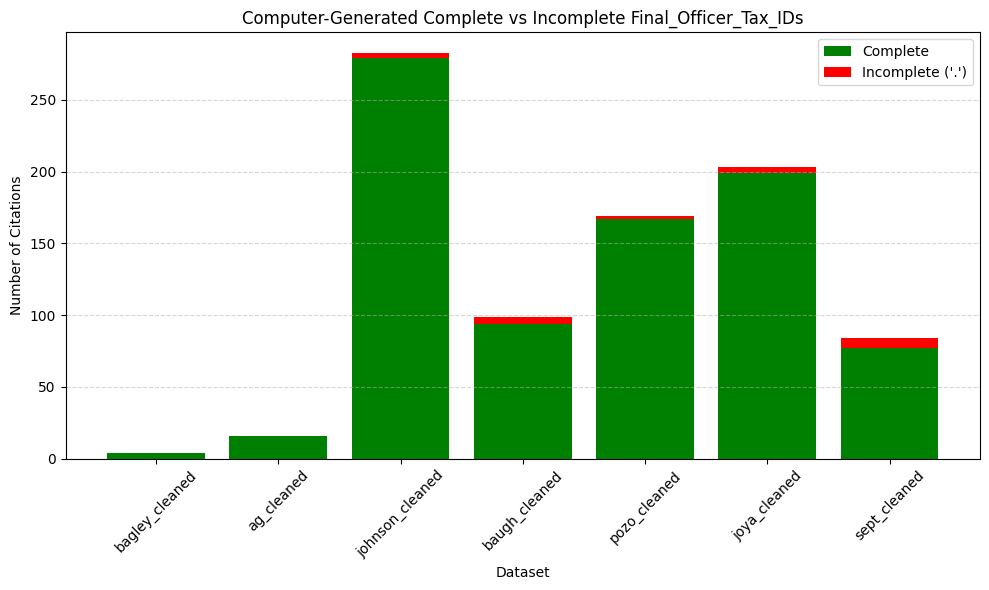

In [ ]:
# Visualization of Computer-Generated Complete vs. Incomplete Final_Officer_Tax_IDs

# Data
labels = summary_df["Dataset"]
complete = summary_df["Complete"]
incomplete = summary_df["Incomplete ('.')"]

# Plot
plt.figure(figsize=(10, 6))
plt.bar(labels, complete, label="Complete", color="green")
plt.bar(labels, incomplete, bottom=complete, label="Incomplete ('.')", color="red")

# Labels and formatting
plt.title("Computer-Generated Complete vs Incomplete Final_Officer_Tax_IDs")
plt.ylabel("Number of Citations")
plt.xlabel("Dataset")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


In [ ]:
# How many Computer-generated citations don’t match a confirmed Tax ID?
# Reframed Question: How many Computer-Generated "Tax_Registry_Number_Tax_ID" values do not match "Final_Officer_Tax_ID" values?
summary = []

for key, df in cleaned_files_dict.items():
    # Filter only computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]

    # Standardize both columns to string for accurate comparison
    comp_gen = comp_gen.copy()
    comp_gen["Final_Officer_Tax_ID_str"] = comp_gen["Final_Officer_Tax_ID"].astype(str).str.strip()
    comp_gen["Tax_Registry_Number_Tax_ID_str"] = comp_gen["Tax_Registry_Number_Tax_ID"].astype(str).str.strip()

    # Count mismatches where the two tax IDs are not equal
    mismatches = comp_gen[comp_gen["Final_Officer_Tax_ID_str"] != comp_gen["Tax_Registry_Number_Tax_ID_str"]]
    num_mismatches = len(mismatches)
    total_y = len(comp_gen)

    # Complete = Final_Officer_Tax_ID is all digits (not ".")
    complete = comp_gen[comp_gen["Final_Officer_Tax_ID"].astype(str).str.isdigit()]
    num_complete = len(complete)

    # Add to summary
    summary.append({
        "Dataset": key,
        "Total Computer-Generated (Y)": total_y,
        "Mismatched": num_mismatches,
        "Matched": num_complete,
        "Match %": round(100 * (total_y - num_mismatches) / total_y, 2) if total_y > 0 else 0,
        "Unmatched %": round(100 * (num_mismatches / total_y), 2) if total_y > 0 else 0
    })

# Create and display the summary
summary_df = pd.DataFrame(summary)
summary_df


,Dataset,Total Computer-Generated (Y),Mismatched,Matched,Match %,Unmatched %
0,bagley_cleaned,4,0,4,100.00,0.00
1,ag_cleaned,16,0,16,100.00,0.00
2,johnson_cleaned,283,21,279,92.58,7.42
3,baugh_cleaned,99,13,94,86.87,13.13
4,pozo_cleaned,169,19,167,88.76,11.24
5,joya_cleaned,207,20,199,90.34,9.66
6,sept_cleaned,85,9,77,89.41,10.59


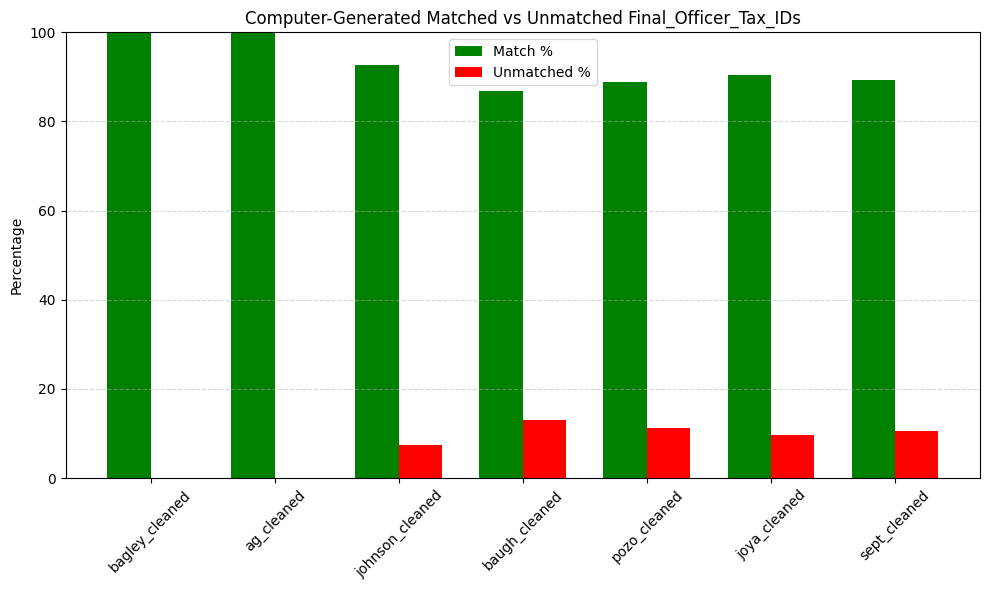

In [ ]:
# Visualization of Computer-Generated Matched vs. Unmatched Final_Officer_Tax_IDs

labels = summary_df["Dataset"]
match = summary_df["Match %"]
unmatch = summary_df["Unmatched %"]

# X locations for bars
x = np.arange(len(labels))
width = 0.35

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, match, width, label='Match %', color='green')
plt.bar(x + width/2, unmatch, width, label='Unmatched %', color='red')

# Labels
plt.xticks(x, labels, rotation=45)
plt.ylabel("Percentage")
plt.title("Computer-Generated Matched vs Unmatched Final_Officer_Tax_IDs")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


In [ ]:
# Checking "If_Computer_Generated" column; Either "." , "Confirmed by Name", "Confirmed with Different ID"

# Iterate over each DataFrame in the dictionary
for file_name, df in cleaned_files_dict.items():
    print(f"Value counts for '{file_name}':")

    # Check if the column exists in the DataFrame
    if 'If_Computer_Generated' in df.columns:
        # Calculate value counts for the specified column
        value_counts = df['If_Computer_Generated'].value_counts(dropna=False)
        print(value_counts)
    else:
        print("Column 'If_Computer_Generated' not found in this DataFrame.")

    print("\n" + "="*50 + "\n")


Value counts for 'bagley_cleaned':
If_Computer_Generated
.    936
Name: count, dtype: int64


Value counts for 'ag_cleaned':
If_Computer_Generated
.                    294
Confirmed by Name      7
NaN                    1
Name: count, dtype: int64


Value counts for 'johnson_cleaned':
If_Computer_Generated
.                              774
NaN                             53
Confirmed by Name               20
Confirmed with Different ID      8
Name: count, dtype: int64


Value counts for 'baugh_cleaned':
If_Computer_Generated
.                              512
Confirmed with Different ID      5
Confirmed by Name                5
NaN                              1
Name: count, dtype: int64


Value counts for 'pozo_cleaned':
If_Computer_Generated
.                              742
Confirmed by Name               19
Confirmed with Different ID     12
Name: count, dtype: int64


Value counts for 'joya_cleaned':
If_Computer_Generated
.                              1434
Confirmed by Name    

In [ ]:
# Out of all computer-generated citations: which were confirmed by "Confirmed by Name", "Confirmed with Different ID", or "." (either)

# Summary list for storing results
summary = []

# Process each DataFrame in the dictionary
for name, df in cleaned_files_dict.items():
    # Make sure key columns are strings
    df["Computer_Generated_YN"] = df["Computer_Generated_YN"].astype(str)
    df["Final_Officer_Tax_ID"] = df["Final_Officer_Tax_ID"].astype(str)
    df["If_Computer_Generated"] = df["If_Computer_Generated"].astype(str)

    # Filter for computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]

    # Further filter: Tax ID must be either a number or "."
    comp_gen_valid_id = comp_gen[comp_gen["Final_Officer_Tax_ID"].str.match(r"^\d+$")]

    # Count types of confirmation
    confirmed_by_name = (comp_gen_valid_id["If_Computer_Generated"] == "Confirmed by Name").sum()
    confirmed_diff_id = (comp_gen_valid_id["If_Computer_Generated"] == "Confirmed with Different ID").sum()
    unknown = (comp_gen_valid_id["If_Computer_Generated"] == ".").sum()
    total = len(comp_gen_valid_id)

    # Append results
    summary.append({
        "File": name,
        "Total Confirmed Computer-Generated w/ Final_Officer_Tax_ID": total,
        "Confirmed by Name": confirmed_by_name,
        "Confirmed with Different ID": confirmed_diff_id,
        "Missing (.)": unknown
    })

# Create and display summary DataFrame
summary_df = pd.DataFrame(summary)
summary_df


,File,Total Confirmed Computer-Generated w/ Final_Officer_Tax_ID,Confirmed by Name,Confirmed with Different ID,Missing (.)
0,bagley_cleaned,4,0,0,4
1,ag_cleaned,16,7,0,9
2,johnson_cleaned,279,20,8,251
3,baugh_cleaned,94,4,5,85
4,pozo_cleaned,167,19,12,136
5,joya_cleaned,199,15,4,180
6,sept_cleaned,77,1,0,76


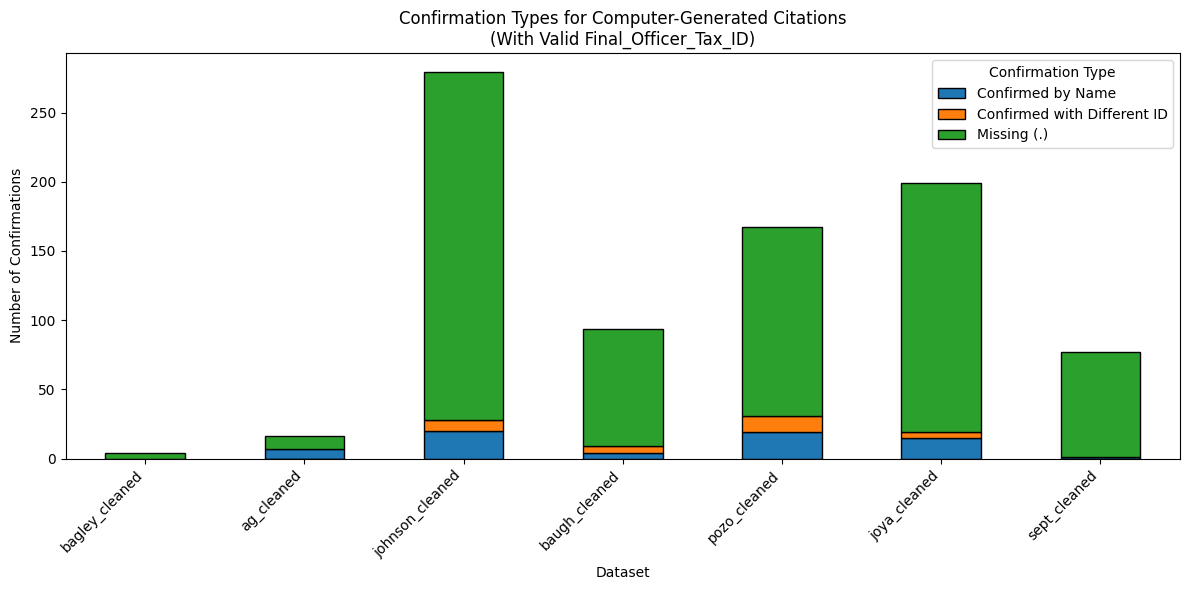

In [ ]:
# Plot
summary_df = summary_df.set_index("File")

# Plot a stacked bar chart
summary_df[["Confirmed by Name", "Confirmed with Different ID", "Missing (.)"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    edgecolor="black"
)

# Chart labels and formatting
plt.title("Confirmation Types for Computer-Generated Citations\n(With Valid Final_Officer_Tax_ID)")
plt.xlabel("Dataset")
plt.ylabel("Number of Confirmations")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Confirmation Type")
plt.tight_layout()

plt.show()


### 3. Replacing Empty Rows (NaN) with "."
- Individually checking empty values (NaN) for each .csv
- Retaining data by replacing NaN's with ".' instead of dropping whole rows with NaN values  
  - Special Case: johnson_cleaned had 53 empty values in "Ticket_Number" column (Dropped)

In [ ]:
cleaned_files_dict["joya_cleaned"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Ticket_Number                   1455 non-null   int64 
 1   Complaintants_First_Name        1450 non-null   object
 2   Complaintants_Last_Name         1455 non-null   object
 3   Tax_Registry_Number_Tax_ID      1455 non-null   object
 4   Agency                          1455 non-null   object
 5   Confidence_on_PO_Name           1455 non-null   object
 6   Confidence_on_Officer_Tax_ID    1455 non-null   object
 7   Alternative_Officer_First_Name  1454 non-null   object
 8   Alternative_Officer_Last_Name   1454 non-null   object
 9   Alternative_Officer_Tax_ID      1453 non-null   object
 10  Verified_Name_w_Tax_ID          1455 non-null   object
 11  Last_Name_First_Name            1455 non-null   object
 12  If_Partial_Illegible_ID         1453 non-null   

#### joya_cleaned NaN Rows

In [ ]:
# joya_cleaned NaN Rows
# cleaned_files_dict["joya_cleaned"].isnull().sum() #Checks which columns have NaN values

# Create a mask to identify rows where any of the specified columns are null
mask = cleaned_files_dict["joya_cleaned"][["Complaintants_First_Name", "Alternative_Officer_First_Name",
                    "Alternative_Officer_Last_Name", "Alternative_Officer_Tax_ID",
                    "If_Partial_Illegible_ID", "Computer_Generated_YN"]].isnull().any(axis=1)

# Apply the mask to filter the DataFrame and display the results
cleaned_files_dict["joya_cleaned"][mask]

# All NaNs are replaced with ".". The next section deals with PDF NOT FOUND / ILLEGIBLE values

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
236,201484342,.,Snow,948099,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Snow, Daniel",NaN,Daniel,Snow,948099,N,.
459,202755805,.,Ford,963994,NYPD,High,High,.,.,NaN,Confirmed Name w/Original ID,"Ford, Gerard",.,Gerard,Ford,963994,N,.
1152,206202050,NaN,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1153,206202069,NaN,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1154,206202078,NaN,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1155,206202087,NaN,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1156,206202096,NaN,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1161,206203260,.,Salman,955435,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Salman, Mohammad",NaN,Mohammad,Salman,955435,Y,.
1388,201278276,.,Azam,955737,NYPD,High,Medium,NaN,NaN,NaN,.,"Azam, Majid",Confirmed w/Command Info Column,Majid,Azam,954511,N,.


In [ ]:
# All joya_cleaned NaNs are replaced with "."
cleaned_files_dict["joya_cleaned"] = cleaned_files_dict["joya_cleaned"].fillna(".")

# Checking if all NaNs are replaced with "."
cleaned_files_dict["joya_cleaned"][mask]

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
236,201484342,.,Snow,948099,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Snow, Daniel",.,Daniel,Snow,948099,N,.
459,202755805,.,Ford,963994,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Ford, Gerard",.,Gerard,Ford,963994,N,.
1152,206202050,.,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1153,206202069,.,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1154,206202078,.,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1155,206202087,.,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1156,206202096,.,Sanchez,928808,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Sanchez, Luis",.,Luis,Sanchez,928808,Y,.
1161,206203260,.,Salman,955435,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Salman, Mohammad",.,Mohammad,Salman,955435,Y,.
1388,201278276,.,Azam,955737,NYPD,High,Medium,.,.,.,.,"Azam, Majid",Confirmed w/Command Info Column,Majid,Azam,954511,N,.


#### ag_cleaned NaN Rows

In [ ]:
# ag_cleaned NaN Rows
cleaned_files_dict["ag_cleaned"].isnull().sum() #Checks which columns have NaN values

# Create a mask to identify rows where any of the specified columns are null
mask = cleaned_files_dict["ag_cleaned"][["Agency", "Confidence_on_PO_Name",
                    "Confidence_on_Officer_Tax_ID", "Alternative_Officer_First_Name",
                    "Alternative_Officer_Last_Name", "Alternative_Officer_Tax_ID",
                    "Verified_Name_w_Tax_ID", "Last_Name_First_Name", "If_Partial_Illegible_ID",
                    "Final_Officer_First_Name", "Final_Officer_Last_Name", "Final_Officer_Tax_ID",
                    "Computer_Generated_YN"]].isnull().any(axis=1)

# Apply the mask to filter the DataFrame and display the results
cleaned_files_dict["ag_cleaned"][mask]

# All NaNs are replaced with ".". The next section deals with PDF NOT FOUND / ILLEGIBLE values

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
35,197775106,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.,.,.,ENTIRE PDF ILLEGIBLE,NaN,.,ENTIRE PDF ILLEGIBLE,.,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.,N,.
79,198403307,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.,.,ENTIRE PDF ILLEGIBLE,NaN,ENTIRE PDF ILLEGIBLE,.,ENTIRE PDF ILLEGIBLE,.,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.,N,.
80,198499218,.,Corusso,969129,NYPD,Medium,Medium,.,.,NaN,Different Name Listed,"Ilyas, Saheer",.,Saheer,Ilyas,969129,N,.
82,198590123,.,Gallors,966583,NYPD,Medium,Medium,.,.\n.\n.\n.\n.\n.\n.\n.,NaN,Different Name Listed,"Gallard, Dimitri",.,Dimitri,Gallard,966583,N,.
83,198611023,.,Carry,960742,NYPD,Medium,Medium,.,.,NaN,Different Name Listed,"Kang, Katlyn",.,Katlyn,Kang,960742,N,.
84,198704010,.,Almanzar,969475,NYPD,Medium,Medium,.,.,NaN,Confirmed Name w/Original ID,"Almanzar, Roberto",.,Roberto,Almanzar,969475,N,.
85,198704532,.,Idowu,969811,NYPD,High,High,.,.,NaN,Confirmed Name w/Original ID,"Idowu, Adesina",.,Adesina,Idowu,969811,N,.
86,198704541,.,Idail,969811,NYPD,Medium,High,.,.,NaN,Different Name Listed,"Idowu, Adesina",.,Adesina,Idowu,969811,N,.
88,199131763,.,Murthy,968031,NYPD,Medium,High,.,.,NaN,Confirmed Name w/Original ID,"Murthy, Viraj",.,Viraj,Murthy,968031,N,.
89,199161079,.,Rellahes,935100,NYPD,Medium,High,.,.,NaN,Different Name Listed,"Kellaher, Justin",.,Justin,Kellaher,935100,N,.


In [ ]:
# All ag_cleaned NaNs are replaced with "."
cleaned_files_dict["ag_cleaned"] = cleaned_files_dict["ag_cleaned"].fillna(".")

# Checking if all NaNs are replaced with "."
cleaned_files_dict["ag_cleaned"][mask]


,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,...,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
35,197775106,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,...,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.,N,.
79,198403307,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,...,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.,N,.
80,198499218,.,Corusso,969129,NYPD,...,Saheer,Ilyas,969129,N,.
82,198590123,.,Gallors,966583,NYPD,...,Dimitri,Gallard,966583,N,.
83,198611023,.,Carry,960742,NYPD,...,Katlyn,Kang,960742,N,.
84,198704010,.,Almanzar,969475,NYPD,...,Roberto,Almanzar,969475,N,.
85,198704532,.,Idowu,969811,NYPD,...,Adesina,Idowu,969811,N,.
86,198704541,.,Idail,969811,NYPD,...,Adesina,Idowu,969811,N,.
88,199131763,.,Murthy,968031,NYPD,...,Viraj,Murthy,968031,N,.
89,199161079,.,Rellahes,935100,NYPD,...,Justin,Kellaher,935100,N,.


#### bagley_cleaned NaN Rows

In [ ]:
# bagley_cleaned NaN Rows
cleaned_files_dict["bagley_cleaned"].isnull().sum() #Checks which columns have NaN values

# Create a mask to identify rows where any of the specified columns are null
mask = cleaned_files_dict["bagley_cleaned"][["Complaintants_First_Name", "If_Partial_Illegible_ID"]].isnull().any(axis=1)

# Apply the mask to filter the DataFrame and display the results
cleaned_files_dict["bagley_cleaned"][mask]

# All NaNs are replaced with ".". The next section deals with PDF NOT FOUND / ILLEGIBLE values

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
144,198616670,PO,Ralan,959701,NYPD,Medium,Low,.,Rala,959709,ID Not Found,.,NaN,.,.,959701,N,.
208,199055919,NaN,Tjortjoglou,959302,NYPD,Low,High,TJ,Ortizoglou,.,Confirmed Name w/Original ID,"Tjortjoglou, Savvas",.,Savvas,Tjortjoglou,959302,N,.


In [ ]:
# All bagley_cleaned NaNs are replaced with "."
cleaned_files_dict["bagley_cleaned"] = cleaned_files_dict["bagley_cleaned"].fillna(".")

# Checking if all NaNs are replaced with "."
cleaned_files_dict["bagley_cleaned"][mask]

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
144,198616670,PO,Ralan,959701,NYPD,Medium,Low,.,Rala,959709,ID Not Found,.,.,.,.,959701,N,.
208,199055919,.,Tjortjoglou,959302,NYPD,Low,High,TJ,Ortizoglou,.,Confirmed Name w/Original ID,"Tjortjoglou, Savvas",.,Savvas,Tjortjoglou,959302,N,.


#### johnson_cleaned NaN Rows
- Special Case: Dataset has 53 empty "Ticket_Number" values, indicating a format or data export error. Those rows are completely empty and are dropped.

In [ ]:
# Noting 53 empty "Ticket_Number" values
cleaned_files_dict["johnson_cleaned"].isnull().sum() #Checks which columns have NaN values

,0
Ticket_Number,53
Complaintants_First_Name,54
Complaintants_Last_Name,53
Tax_Registry_Number_Tax_ID,53
Agency,53
Confidence_on_PO_Name,53
Confidence_on_Officer_Tax_ID,53
Alternative_Officer_First_Name,1
Alternative_Officer_Last_Name,1
Alternative_Officer_Tax_ID,0


In [ ]:
# johnson_cleaned NaN Rows
cleaned_files_dict["johnson_cleaned"].isnull().sum() #Checks which columns have NaN values

# Create a mask to identify rows where any of the specified columns are null
mask = cleaned_files_dict["johnson_cleaned"][["Complaintants_First_Name", "Alternative_Officer_First_Name", "Alternative_Officer_Last_Name"]].isnull().any(axis=1)

# Apply the mask to filter the DataFrame and display the results
cleaned_files_dict["johnson_cleaned"][mask]


,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
24,196710571.0,.,Reyes Estrada,967651,NYPD,Medium,High,NaN,NaN,967659,Confirmed Name w/Alternative ID,"Reyesestrada, Edwin",.,Edwin,Reyesestrada,967659,N,.
579,214851827.0,NaN,Soldano,961311,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Soldano, Joseph",.,Joseph,Soldano,961311,N,.
802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,NaN,NaN,.,NaN,NaN,nan,nan,nan
803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,NaN,NaN,.,NaN,NaN,nan,nan,nan
804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,NaN,NaN,.,NaN,NaN,nan,nan,nan
805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,NaN,NaN,.,NaN,NaN,nan,nan,nan
806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,NaN,NaN,.,NaN,NaN,nan,nan,nan
807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,NaN,NaN,.,NaN,NaN,nan,nan,nan
808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,NaN,NaN,.,NaN,NaN,nan,nan,nan
809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,NaN,NaN,.,NaN,NaN,nan,nan,nan


In [ ]:
# Special Case: Dropping all rows with NaN in "Ticket_Number" column (empty columns in her spreadsheet with no citation ticket #)
cleaned_files_dict["johnson_cleaned"] = cleaned_files_dict["johnson_cleaned"].dropna(subset=["Ticket_Number"])

# Replacing all NaNs in rows where "Final_Officer_Tax_ID" is complete
cleaned_files_dict["johnson_cleaned"] = cleaned_files_dict["johnson_cleaned"].fillna(".")

# Checking if all NaNs are replaced with "."
cleaned_files_dict["johnson_cleaned"].isnull().sum()

,0
Ticket_Number,0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0


#### baugh_cleaned NaN Rows

In [ ]:
# baugh_cleaned NaN Rows
cleaned_files_dict["baugh_cleaned"].isnull().sum() #Checks which columns have NaN values

# Create a mask to identify rows where any of the specified columns are null
mask = cleaned_files_dict["baugh_cleaned"][["Complaintants_First_Name", "If_Partial_Illegible_ID"]].isnull().any(axis=1)

# Apply the mask to filter the DataFrame and display the results
cleaned_files_dict["baugh_cleaned"][mask]

# No missing values; No NaNs are replaced with "."

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated


#### pozo_cleaned NaN Rows

In [ ]:
# pozo_cleaned NaN Rows
cleaned_files_dict["pozo_cleaned"].isnull().sum() #Checks which columns have NaN values

# Create a mask to identify rows where any of the specified columns are null
mask = cleaned_files_dict["pozo_cleaned"][["Complaintants_First_Name", "If_Partial_Illegible_ID"]].isnull().any(axis=1)

# Apply the mask to filter the DataFrame and display the results
cleaned_files_dict["pozo_cleaned"][mask]


,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
187,207809288,.,Clanell,969019,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"Clavell, Justin",NaN,Justin,Clavell,969019,N,.
322,202889491,NaN,Natsulikshvici,965814,NYPD,Medium,High,.,Natsvlishvici,.,Confirmed Name w/Original ID,"Natsvlishvili, Sergi",.,Sergi,Natsvlishvili,965814,N,.
333,211913287,.,Hernandez Rivas,971093,NYPD,High,High,.,.,.,Confirmed Name w/Original ID,"HernandezRivas, Ashley",NaN,Ashley,HernandezRivas,971093,N,.


In [ ]:
# All pozo_cleaned NaNs are replaced with "."
cleaned_files_dict["pozo_cleaned"] = cleaned_files_dict["pozo_cleaned"].fillna(".")

# Checking if all NaNs are replaced with "."
cleaned_files_dict["pozo_cleaned"][mask]

# All NaNs are replaced with ".".
cleaned_files_dict["pozo_cleaned"].isnull().sum()

,0
Ticket_Number,0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0


### sept_cleaned NaN rows

In [ ]:
# sept_cleaned NaN Rows
cleaned_files_dict["sept_cleaned"].isnull().sum() #Checks which columns have NaN values

# Create a mask to identify rows where any of the specified columns are null
mask = cleaned_files_dict["sept_cleaned"][["Complaintants_First_Name", "If_Partial_Illegible_ID"]].isnull().any(axis=1)

# Apply the mask to filter the DataFrame and display the results
cleaned_files_dict["sept_cleaned"][mask]

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
16,199083290,.,Pontisakos,965423,NYPD,Medium,Medium,.,.,.,Confirmed Name w/Original ID,"Pontisakos, Michael",NaN,Michael,Pontisakos,965423,N,.


In [ ]:
# All sept_cleaned NaNs are replaced with "."
cleaned_files_dict["sept_cleaned"] = cleaned_files_dict["sept_cleaned"].fillna(".")

# Checking if all NaNs are replaced with "."
cleaned_files_dict["sept_cleaned"][mask]

# All NaNs are replaced with ".".
cleaned_files_dict["sept_cleaned"].isnull().sum()

In [ ]:
# Stage 2 Check

# Rename 'Rows' column to 'Stage 1 Rows'
stage_1_check = stage_1_check.rename(columns={"Rows": "Stage 1 Rows"})

# Build Stage 2 check using the same cleaned_files_dict
stage_2_check = []

for file_name, df in cleaned_files_dict.items():
    stage_2_check.append({
        "File Name": file_name,
        "Stage 2 Rows": df.shape[0]
    })

stage_2_check = pd.DataFrame(stage_2_check)

# Add total row to Stage 2
stage_2_total = pd.DataFrame([{
    "File Name": "Total",
    "Stage 2 Rows": stage_2_check["Stage 2 Rows"].sum()
}])

stage_2_check = pd.concat([stage_2_check, stage_2_total], ignore_index=True)

# Merge with stage_1_check (which already has the 'Total' row)
stage_comparison = pd.merge(stage_1_check, stage_2_check, on="File Name")

# Display the result
stage_comparison





,File Name,Stage 1 Rows,Stage 2 Rows
0,bagley_cleaned,936,936
1,ag_cleaned,302,302
2,johnson_cleaned,855,802
3,baugh_cleaned,523,523
4,pozo_cleaned,773,773
5,joya_cleaned,1455,1455
6,sept_cleaned,526,526
7,Total,5370,5317


### 4. Checking for Duplicate Rows
- No duplicate rows found; meaning all Ticket_Number values are unique

In [ ]:
# Checking for Unique
for key, df in cleaned_files_dict.items():
    total = len(df)
    unique = df["Ticket_Number"].nunique()
    duplicates = total - unique

    print(f"{key}:")
    print(f"  Total rows: {total}")
    print(f"  Unique Ticket_Numbers: {unique}")
    print(f"  Duplicates: {duplicates}")
    print("-" * 40)


bagley_cleaned:
  Total rows: 936
  Unique Ticket_Numbers: 936
  Duplicates: 0
----------------------------------------
ag_cleaned:
  Total rows: 302
  Unique Ticket_Numbers: 302
  Duplicates: 0
----------------------------------------
johnson_cleaned:
  Total rows: 802
  Unique Ticket_Numbers: 802
  Duplicates: 0
----------------------------------------
baugh_cleaned:
  Total rows: 523
  Unique Ticket_Numbers: 523
  Duplicates: 0
----------------------------------------
pozo_cleaned:
  Total rows: 773
  Unique Ticket_Numbers: 773
  Duplicates: 0
----------------------------------------
joya_cleaned:
  Total rows: 1455
  Unique Ticket_Numbers: 1455
  Duplicates: 0
----------------------------------------


In [ ]:
# Stage 3 Check

# Rename 'Rows' column to 'Stage 1 Rows'
stage_2_check = stage_2_check.rename(columns={"Rows": "Stage 2 Rows"})

# Build Stage 2 check using the same cleaned_files_dict
stage_3_check = []

for file_name, df in cleaned_files_dict.items():
    stage_3_check.append({
        "File Name": file_name,
        "Stage 3 Rows": df.shape[0]
    })

stage_3_check = pd.DataFrame(stage_3_check)

# Add total row to Stage 2
stage_3_total = pd.DataFrame([{
    "File Name": "Total",
    "Stage 3 Rows": stage_3_check["Stage 3 Rows"].sum()
}])

stage_3_check = pd.concat([stage_3_check, stage_3_total], ignore_index=True)

# Merge with stage_1_check (which already has the 'Total' row)
stage_comparison = pd.merge(stage_1_check, stage_2_check, on="File Name").merge(stage_3_check, on="File Name")

# Display the result
stage_comparison


,File Name,Stage 1 Rows,Stage 2 Rows,Stage 3 Rows
0,bagley_cleaned,936,936,936
1,ag_cleaned,302,302,302
2,johnson_cleaned,855,802,802
3,baugh_cleaned,523,523,523
4,pozo_cleaned,773,773,773
5,joya_cleaned,1455,1455,1455
6,Total,4844,4791,4791


#### Computer-Generated Validity Inquiry pt. 2

In [ ]:
# How many Computer-generated citations do not have confirmed "Final_Officer_Tax_ID"?
summary = []

for key, df in cleaned_files_dict.items():
    # Filter computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]
    total_y = len(comp_gen)

    # Incomplete = Final_Officer_Tax_ID == "."
    incomplete = comp_gen[comp_gen["Final_Officer_Tax_ID"] == "."]
    num_incomplete = len(incomplete)

    # Complete = Final_Officer_Tax_ID is all digits (not ".")
    complete = comp_gen[comp_gen["Final_Officer_Tax_ID"].astype(str).str.isdigit()]
    num_complete = len(complete)

    # Add to summary
    summary.append({
        "Dataset": key,
        "Computer_Generated (Y)": total_y,
        "Incomplete ('.')": num_incomplete,
        "Complete": num_complete,
        "Complete %": round((num_complete / total_y) * 100, 2) if total_y > 0 else 0
    })

# Create the DataFrame summary
summary_df = pd.DataFrame(summary)
summary_df


,Dataset,Computer_Generated (Y),Incomplete ('.'),Complete,Complete %
0,bagley_cleaned,4,0,4,100.00
1,ag_cleaned,16,0,16,100.00
2,johnson_cleaned,283,4,279,98.59
3,baugh_cleaned,99,5,94,94.95
4,pozo_cleaned,169,2,167,98.82
5,joya_cleaned,207,4,199,96.14


In [ ]:
# How many Computer-generated citations don’t match a confirmed Tax ID?
# Reframed Question: How many Computer-Generated "Tax_Registry_Number_Tax_ID" values do not match "Tax_Registry_Number_Tax_ID" values?
summary = []

for key, df in cleaned_files_dict.items():
    # Filter only computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]

    # Standardize both columns to string for accurate comparison
    comp_gen = comp_gen.copy()
    comp_gen["Final_Officer_Tax_ID_str"] = comp_gen["Final_Officer_Tax_ID"].astype(str).str.strip()
    comp_gen["Tax_Registry_Number_Tax_ID_str"] = comp_gen["Tax_Registry_Number_Tax_ID"].astype(str).str.strip()

    # Count mismatches where the two tax IDs are not equal
    mismatches = comp_gen[comp_gen["Final_Officer_Tax_ID_str"] != comp_gen["Tax_Registry_Number_Tax_ID_str"]]
    num_mismatches = len(mismatches)
    total_y = len(comp_gen)

    # Complete = Final_Officer_Tax_ID is all digits (not ".")
    complete = comp_gen[comp_gen["Final_Officer_Tax_ID"].astype(str).str.isdigit()]
    num_complete = len(complete)

    # Add to summary
    summary.append({
        "Dataset": key,
        "Total Computer-Generated (Y)": total_y,
        "Mismatched": num_mismatches,
        "Matched": num_complete,
        "Match %": round(100 * (total_y - num_mismatches) / total_y, 2) if total_y > 0 else 0,
        "Unmatched %": round(100 * (num_mismatches / total_y), 2) if total_y > 0 else 0
    })

# Create and display the summary
summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Total Computer-Generated (Y),Mismatched,Matched,Match %,Unmatched %
0,bagley_cleaned,4,0,4,100.00,0.00
1,ag_cleaned,16,0,16,100.00,0.00
2,johnson_cleaned,283,21,279,92.58,7.42
3,baugh_cleaned,99,13,94,86.87,13.13
4,pozo_cleaned,169,19,167,88.76,11.24
5,joya_cleaned,207,20,199,90.34,9.66


### 5. Isolating "Final_Officer_Tax_ID" Numeric Values
* Identifying how many "." or numeric values are in the "Final_Officer_Tax_ID" column for each file
* Drops all rows that contain "." in "Final_Officer_Tax_ID" column; No determined Officer from Civil Citation
* Retaining rows with integer "Final_Officer_Tax_ID"



In [ ]:
cleaned_files_dict["pozo_cleaned"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Ticket_Number                   773 non-null    int64 
 1   Complaintants_First_Name        773 non-null    object
 2   Complaintants_Last_Name         773 non-null    object
 3   Tax_Registry_Number_Tax_ID      773 non-null    object
 4   Agency                          773 non-null    object
 5   Confidence_on_PO_Name           773 non-null    object
 6   Confidence_on_Officer_Tax_ID    773 non-null    object
 7   Alternative_Officer_First_Name  773 non-null    object
 8   Alternative_Officer_Last_Name   773 non-null    object
 9   Alternative_Officer_Tax_ID      773 non-null    object
 10  Verified_Name_w_Tax_ID          773 non-null    object
 11  Last_Name_First_Name            773 non-null    object
 12  If_Partial_Illegible_ID         773 non-null    ob

#### joya_cleaned "Final_Officer_Tax_ID" Values
- 1401 numeric Final_Officer_Tax_IDs
- 40 "." values in Final_Officer_Tax_IDs (dropped)

In [ ]:
# Convert to string first for consistency
final_officer_col = cleaned_files_dict["joya_cleaned"]["Final_Officer_Tax_ID"].astype(str)

# Count numeric values
numeric_count = final_officer_col.str.isdigit().sum()

# Count "." values
dot_count = (final_officer_col == ".").sum()

# Display counts
print(f"Number of numeric Final_Officer_Tax_IDs: {numeric_count}")
print(f"Number of '.' in Final_Officer_Tax_IDs: {dot_count}")


Number of numeric Final_Officer_Tax_IDs: 1401
Number of '.' in Final_Officer_Tax_IDs: 40


In [ ]:
# Dropping rows where "." is in "Final_Officer_Tax_ID" column
cleaned_files_dict["joya_cleaned"] = cleaned_files_dict["joya_cleaned"][
    cleaned_files_dict["joya_cleaned"]["Final_Officer_Tax_ID"] != "."
]

# Resetting index
cleaned_files_dict["joya_cleaned"] = cleaned_files_dict["joya_cleaned"].reset_index(drop=True)

# Checking if all rows where Final_Officer_Tax_ID is "." are dropped
cleaned_files_dict["joya_cleaned"][cleaned_files_dict["joya_cleaned"]["Final_Officer_Tax_ID"] == "."].sum()


,0
Ticket_Number,0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0


#### ag_cleaned "Final_Officer_Tax_ID" Values
- 288 numeric Final_Officer_Tax_IDs
- 10 "." values in Final_Officer_Tax_IDs (Dropped)


In [ ]:
# Convert to string first for consistency
final_officer_col = cleaned_files_dict["ag_cleaned"]["Final_Officer_Tax_ID"].astype(str)

# Count numeric values
numeric_count = final_officer_col.str.isdigit().sum()

# Count "." values
dot_count = (final_officer_col == ".").sum()

# Display counts
print(f"Number of numeric Final_Officer_Tax_IDs: {numeric_count}")
print(f"Number of '.' in Final_Officer_Tax_IDs: {dot_count}")

Number of numeric Final_Officer_Tax_IDs: 288
Number of '.' in Final_Officer_Tax_IDs: 9


In [ ]:
# Dropping rows where "." is in "Final_Officer_Tax_ID" column
cleaned_files_dict["ag_cleaned"] = cleaned_files_dict["ag_cleaned"][
    cleaned_files_dict["ag_cleaned"]["Final_Officer_Tax_ID"] != "."
]

# Resetting index
cleaned_files_dict["ag_cleaned"] = cleaned_files_dict["ag_cleaned"].reset_index(drop=True)

# Checking if all rows where Final_Officer_Tax_ID is "." are dropped
cleaned_files_dict["ag_cleaned"][cleaned_files_dict["ag_cleaned"]["Final_Officer_Tax_ID"] == "."].sum()


,0
Ticket_Number,0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0


#### bagley_cleaned "Final_Officer_Tax_ID" Values
- 925 numeric Final_Officer_Tax_IDs
- 10 "." values in Final_Officer_Tax_IDs (Dropped)

In [ ]:
# Convert to string first for consistency
final_officer_col = cleaned_files_dict["bagley_cleaned"]["Final_Officer_Tax_ID"].astype(str)

# Count numeric values
numeric_count = final_officer_col.str.isdigit().sum()

# Count "." values
dot_count = (final_officer_col == ".").sum()

# Display counts
print(f"Number of numeric Final_Officer_Tax_IDs: {numeric_count}")
print(f"Number of '.' in Final_Officer_Tax_IDs: {dot_count}")

Number of numeric Final_Officer_Tax_IDs: 925
Number of '.' in Final_Officer_Tax_IDs: 10


In [ ]:
# Dropping rows where "." is in "Final_Officer_Tax_ID" column
cleaned_files_dict["bagley_cleaned"] = cleaned_files_dict["bagley_cleaned"][
    cleaned_files_dict["bagley_cleaned"]["Final_Officer_Tax_ID"] != "."
]

# Resetting index
cleaned_files_dict["bagley_cleaned"] = cleaned_files_dict["bagley_cleaned"].reset_index(drop=True)

# Checking if all rows where Final_Officer_Tax_ID is "." are dropped
cleaned_files_dict["bagley_cleaned"][cleaned_files_dict["bagley_cleaned"]["Final_Officer_Tax_ID"] == "."].sum()


,0
Ticket_Number,0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0


#### johnson_cleaned "Final_Officer_Tax_ID" Values
- 785 numeric Final_Officer_Tax_IDs
- 17 "." values in Final_Officer_Tax_IDs (Dropped)

In [ ]:
# Convert to string first for consistency
final_officer_col = cleaned_files_dict["johnson_cleaned"]["Final_Officer_Tax_ID"].astype(str)

# Count numeric values
numeric_count = final_officer_col.str.isdigit().sum()

# Count "." values
dot_count = (final_officer_col == ".").sum()

# Display counts
print(f"Number of numeric Final_Officer_Tax_IDs: {numeric_count}")
print(f"Number of '.' in Final_Officer_Tax_IDs: {dot_count}")

Number of numeric Final_Officer_Tax_IDs: 785
Number of '.' in Final_Officer_Tax_IDs: 17


In [ ]:
# Dropping rows where "." is in "Final_Officer_Tax_ID" column
cleaned_files_dict["johnson_cleaned"] = cleaned_files_dict["johnson_cleaned"][
    cleaned_files_dict["johnson_cleaned"]["Final_Officer_Tax_ID"] != "."
]

# Resetting index
cleaned_files_dict["johnson_cleaned"] = cleaned_files_dict["johnson_cleaned"].reset_index(drop=True)

# Checking if all rows where Final_Officer_Tax_ID is "." are dropped
cleaned_files_dict["johnson_cleaned"][cleaned_files_dict["johnson_cleaned"]["Final_Officer_Tax_ID"] == "."].sum()


,0
Ticket_Number,0.0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0


#### baugh_cleaned "Final_Officer_Tax_ID" Values
- 498 numeric Final_Officer_Tax_IDs
- 19 "." values in Final_Officer_Tax_IDs (Dropped)

In [ ]:
# Convert to string first for consistency
final_officer_col = cleaned_files_dict["baugh_cleaned"]["Final_Officer_Tax_ID"].astype(str)

# Count numeric values
numeric_count = final_officer_col.str.isdigit().sum()

# Count "." values
dot_count = (final_officer_col == ".").sum()

# Display counts
print(f"Number of numeric Final_Officer_Tax_IDs: {numeric_count}")
print(f"Number of '.' in Final_Officer_Tax_IDs: {dot_count}")

Number of numeric Final_Officer_Tax_IDs: 498
Number of '.' in Final_Officer_Tax_IDs: 19


In [ ]:
# Dropping rows where "." is in "Final_Officer_Tax_ID" column
cleaned_files_dict["baugh_cleaned"] = cleaned_files_dict["baugh_cleaned"][
    cleaned_files_dict["baugh_cleaned"]["Final_Officer_Tax_ID"] != "."
]

# Resetting index
cleaned_files_dict["baugh_cleaned"] = cleaned_files_dict["baugh_cleaned"].reset_index(drop=True)

# Checking if all rows where Final_Officer_Tax_ID is "." are dropped
cleaned_files_dict["baugh_cleaned"][cleaned_files_dict["baugh_cleaned"]["Final_Officer_Tax_ID"] == "."].sum()


,0
Ticket_Number,0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0


#### pozo_cleaned "Final_Officer_Tax_ID" Values
- 753 numeric Final_Officer_Tax_IDs
- 19 "." values in Final_Officer_Tax_IDs (Dropped)



In [ ]:
# Convert to string first for consistency
final_officer_col = cleaned_files_dict["pozo_cleaned"]["Final_Officer_Tax_ID"].astype(str)

# Count numeric values
numeric_count = final_officer_col.str.isdigit().sum()

# Count "." values
dot_count = (final_officer_col == ".").sum()

# Display counts
print(f"Number of numeric Final_Officer_Tax_IDs: {numeric_count}")
print(f"Number of '.' in Final_Officer_Tax_IDs: {dot_count}")

Number of numeric Final_Officer_Tax_IDs: 753
Number of '.' in Final_Officer_Tax_IDs: 19


In [ ]:
# Dropping rows where "." is in "Final_Officer_Tax_ID" column
cleaned_files_dict["pozo_cleaned"] = cleaned_files_dict["pozo_cleaned"][
    cleaned_files_dict["pozo_cleaned"]["Final_Officer_Tax_ID"] != "."
]

# Resetting index
cleaned_files_dict["pozo_cleaned"] = cleaned_files_dict["pozo_cleaned"].reset_index(drop=True)

# Checking if all rows where Final_Officer_Tax_ID is "." are dropped
cleaned_files_dict["pozo_cleaned"][cleaned_files_dict["pozo_cleaned"]["Final_Officer_Tax_ID"] == "."].sum()


,0
Ticket_Number,0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0


#### Computer-Generated Validity Inquiry pt. 3

- Complete and Match rates improve after dropping NaN values and cleaning "Final_Officer_Tax_ID"

In [ ]:
# How many Computer-generated citations do not have confirmed "Final_Officer_Tax_ID"?
summary = []

for key, df in cleaned_files_dict.items():
    # Filter computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]
    total_y = len(comp_gen)

    # Incomplete = Final_Officer_Tax_ID == "."
    incomplete = comp_gen[comp_gen["Final_Officer_Tax_ID"] == "."]
    num_incomplete = len(incomplete)

    # Complete = Final_Officer_Tax_ID is all digits (not ".")
    complete = comp_gen[comp_gen["Final_Officer_Tax_ID"].astype(str).str.isdigit()]
    num_complete = len(complete)

    # Add to summary
    summary.append({
        "Dataset": key,
        "Computer_Generated (Y)": total_y,
        "Incomplete ('.')": num_incomplete,
        "Complete": num_complete,
        "Complete %": round((num_complete / total_y) * 100, 2) if total_y > 0 else 0
    })

# Create the DataFrame summary
summary_df = pd.DataFrame(summary)
summary_df


,Dataset,Computer_Generated (Y),Incomplete ('.'),Complete,Complete %
0,bagley_cleaned,4,0,4,100.00
1,ag_cleaned,16,0,16,100.00
2,johnson_cleaned,279,0,279,100.00
3,baugh_cleaned,94,0,94,100.00
4,pozo_cleaned,167,0,167,100.00
5,joya_cleaned,203,0,199,98.03


In [ ]:
# How many Computer-generated citations don’t match a confirmed Tax ID?
# Reframed Question: How many Computer-Generated "Tax_Registry_Number_Tax_ID" values do not match "Tax_Registry_Number_Tax_ID" values?
summary = []

for key, df in cleaned_files_dict.items():
    # Filter only computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]

    # Standardize both columns to string for accurate comparison
    comp_gen = comp_gen.copy()
    comp_gen["Final_Officer_Tax_ID_str"] = comp_gen["Final_Officer_Tax_ID"].astype(str).str.strip()
    comp_gen["Tax_Registry_Number_Tax_ID_str"] = comp_gen["Tax_Registry_Number_Tax_ID"].astype(str).str.strip()

    # Count mismatches where the two tax IDs are not equal
    mismatches = comp_gen[comp_gen["Final_Officer_Tax_ID_str"] != comp_gen["Tax_Registry_Number_Tax_ID_str"]]
    num_mismatches = len(mismatches)
    total_y = len(comp_gen)

    # Complete = Final_Officer_Tax_ID is all digits (not ".")
    complete = comp_gen[comp_gen["Final_Officer_Tax_ID"].astype(str).str.isdigit()]
    num_complete = len(complete)

    # Add to summary
    summary.append({
        "Dataset": key,
        "Total Computer-Generated (Y)": total_y,
        "Mismatched": num_mismatches,
        "Matched": num_complete,
        "Match %": round(100 * (total_y - num_mismatches) / total_y, 2) if total_y > 0 else 0,
        "Unmatched %": round(100 * (num_mismatches / total_y), 2) if total_y > 0 else 0
    })

# Create and display the summary
summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Total Computer-Generated (Y),Mismatched,Matched,Match %,Unmatched %
0,bagley_cleaned,4,0,4,100.00,0.00
1,ag_cleaned,16,0,16,100.00,0.00
2,johnson_cleaned,279,17,279,93.91,6.09
3,baugh_cleaned,94,9,94,90.43,9.57
4,pozo_cleaned,167,17,167,89.82,10.18
5,joya_cleaned,203,16,199,92.12,7.88


In [ ]:
# Stage 4 Check

# Rename 'Rows' column to 'Stage 1 Rows'
stage_3_check = stage_3_check.rename(columns={"Rows": "Stage 3 Rows"})

# Build Stage 2 check using the same cleaned_files_dict
stage_4_check = []

for file_name, df in cleaned_files_dict.items():
    stage_4_check.append({
        "File Name": file_name,
        "Stage 4 Rows": df.shape[0]
    })

stage_4_check = pd.DataFrame(stage_4_check)

# Add total row to Stage 2
stage_4_total = pd.DataFrame([{
    "File Name": "Total",
    "Stage 4 Rows": stage_4_check["Stage 4 Rows"].sum()
}])

stage_4_check = pd.concat([stage_4_check, stage_4_total], ignore_index=True)

# Merge with stage_1_check (which already has the 'Total' row)
stage_comparison = stage_1_check.merge(stage_2_check, on="File Name") \
                                .merge(stage_3_check, on="File Name") \
                                .merge(stage_4_check, on="File Name")

# Display the result
stage_comparison

,File Name,Stage 1 Rows,Stage 2 Rows,Stage 3 Rows,Stage 4 Rows
0,bagley_cleaned,936,936,936,926
1,ag_cleaned,302,302,302,293
2,johnson_cleaned,855,802,802,785
3,baugh_cleaned,523,523,523,504
4,pozo_cleaned,773,773,773,754
5,joya_cleaned,1455,1455,1455,1415
6,Total,4844,4791,4791,4677


### 6. Correcting "Illegible" & "PDF Not Found" Values

* Checks all variations of language indicating either illegible or not found PDFs for each file.

All variations include:
1. ILLEGIBLE (no case)
2. PDF NOT FOUND
3. ENTIRE PDF ILLEGIBLE
4. NO IMAGE FOUND
5. NO PDF FOUND
6. NOT FOUND
7. PDF ILLEGIBLE
  * After cleaning "Final_Officer_Tax_ID" for non-integer values, many not found PDFs values were dropped.
* After checking use, either retain by replacing variation with "."s; if integer values in "Final_Officer_Tax_ID"



Codebook details use: ENTIRE PDF ILLEGIBLE or NO IMAGE FOUND or illegible

Different variations:

- **joya_cleaned**: drop PDF NOT FOUND. Replace ILLEGIBLE with "."
- **bagley_cleaned** : drop ENTIRE PDF ILLEGIBLE and NO PDF FOUND
- **baugh_cleaned** : drop ENTIRE PDF ILLEGIBLE and NOT FOUND and  ILLEGIBLE
- **ag_cleaned** : drop ENTIRE PDF ILLEGIBLE and PDF ILLEGIBLE. Replace Illegible => "."
- **pozo_cleaned** : drop NO IMAGE FOUND. Search ILLEGIBLE to either replace => "." or drop row
- **johnson_cleaned** : drop ENTIRE PDF ILLEGIBLE and PDF NOT FOUND. Replace ILLEGIBLE => "."


In [ ]:
cleaned_files_dict["pozo_cleaned"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Ticket_Number                   754 non-null    int64 
 1   Complaintants_First_Name        754 non-null    object
 2   Complaintants_Last_Name         754 non-null    object
 3   Tax_Registry_Number_Tax_ID      754 non-null    object
 4   Agency                          754 non-null    object
 5   Confidence_on_PO_Name           754 non-null    object
 6   Confidence_on_Officer_Tax_ID    754 non-null    object
 7   Alternative_Officer_First_Name  754 non-null    object
 8   Alternative_Officer_Last_Name   754 non-null    object
 9   Alternative_Officer_Tax_ID      754 non-null    object
 10  Verified_Name_w_Tax_ID          754 non-null    object
 11  Last_Name_First_Name            754 non-null    object
 12  If_Partial_Illegible_ID         754 non-null    ob

#### joya_cleaned "Illegible" Values
- "ILLEGIBLE" contained integer values in "Final_Officer_Tax_ID" column; Replaced with ".")

In [ ]:
# Checking joya_cleaned "illegible" values
illegible_or_no_pdf_matches = cleaned_files_dict["joya_cleaned"].apply(
    lambda x: x.astype(str).str.contains("ILLEGIBLE|PDF NOT FOUND|ENTIRE PDF ILLEGIBLE|NO IMAGE FOUND|NO PDF FOUND|NOT FOUND|PDF ILLEGIBLE", case=False, na=False)
)

# Filter and display the rows
matches = cleaned_files_dict["joya_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
206,206167015,.,Lin,ILLEGIBLE,NYPD,High,.,.,.,.,.,"Lin, Shuyi",Confirmed w/Command Info Column,Shuyi,Lin,954069,N,.
247,203342352,.,Nugent,ILLEGIBLE,NYPD,High,High,.,.,.,.,"Nugent, Joseph",Confirmed w/Command Info Column,Joseph,Nugent,966244,N,.
262,201568831,.,Romero,ILLEGIBLE,NYPD,Low,.,.,.,.,.,"Romero, Jimmy",Confirmed w/Command Info Column,Jimmy,Romero,962062,N,.
263,201568840,.,Romero,ILLEGIBLE,NYPD,Low,.,.,.,.,.,"Romero, Jimmy",Confirmed w/Command Info Column,Jimmy,Romero,962062,N,.
853,211743227,.,Canzieno,957752,NYPD,High,High,.,.,.,ID Not Found,"Lanzieri, Vincent",.,Vincent,Lanzieri,957758,Y,Confirmed by Name


In [ ]:
# Replace "." with "ILLEGIBLE" in all columns
cleaned_files_dict["joya_cleaned"] = cleaned_files_dict["joya_cleaned"].replace("ILLEGIBLE", ".")

# Check replacement
matches = cleaned_files_dict["joya_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
206,206167015,.,Lin,.,NYPD,High,.,.,.,.,.,"Lin, Shuyi",Confirmed w/Command Info Column,Shuyi,Lin,954069,N,.
247,203342352,.,Nugent,.,NYPD,High,High,.,.,.,.,"Nugent, Joseph",Confirmed w/Command Info Column,Joseph,Nugent,966244,N,.
262,201568831,.,Romero,.,NYPD,Low,.,.,.,.,.,"Romero, Jimmy",Confirmed w/Command Info Column,Jimmy,Romero,962062,N,.
263,201568840,.,Romero,.,NYPD,Low,.,.,.,.,.,"Romero, Jimmy",Confirmed w/Command Info Column,Jimmy,Romero,962062,N,.
853,211743227,.,Canzieno,957752,NYPD,High,High,.,.,.,ID Not Found,"Lanzieri, Vincent",.,Vincent,Lanzieri,957758,Y,Confirmed by Name


#### ag_cleaned "Illegible" Values
- "Illegible" contained integer values in "Final_Officer_Tax_ID" column; Replaced with ".")
- Drop rows that contain "ENTIRE PDF ILLEGIBLE" "PDF ILLEGIBLE" "ILLEGIBLE"; No integer values in "Final_Officer_Tax_ID" column (Dropped)

In [ ]:
# Checking ag_cleaned "illegible" values
illegible_or_no_pdf_matches = cleaned_files_dict["ag_cleaned"].apply(
    lambda x: x.astype(str).str.contains("ILLEGIBLE|PDF NOT FOUND|ENTIRE PDF ILLEGIBLE|NO IMAGE FOUND|NO PDF FOUND|NOT FOUND|PDF ILLEGIBLE", case=False, na=False)
)

# Filter and display the rows
matches = cleaned_files_dict["ag_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
111,199693890,.,Illegible,962869,NYPD,.,Medium,.,.,.,.,"Waskowitz, Marc",.,Marc,Waskowitz,962867,N,.
119,199786162,.,Illegible,936403,NYPD,.,Medium,.,.,.,.,"Azzarelli, Vincent",Confirmed w/Command Info Column,Vincent,Azzarelli,956403,N,.
124,199820327,.,Illegible,959840,NYPD,Medium,Medium,.,.,.,Confirmed Name w/Original ID,"Nath, Shashawta",.,Shashawta,Nath,959840,N,.
170,200940796,.,Illegible,950654,NYPD,Low,Medium,.,.,.,.,"Jurkota, Christopher",Confirmed w/Command Info Column,Christopher,Jurkota,950654,N,.
180,201175188,.,Romero,Illegible,NYPD,Medium,Low,.,.,.,.,"Romero, Giovanni",.,Giovanni,Romero,967672,N,.
202,201525217,.,Illegible,961771,NYPD,.,Low,.,.,.,.,"Davenport, Shauna",Confirmed w/Command Info Column,Shauna,Davenport,961721,N,.
204,201525253,.,Illegible,962571,NYPD,.,High,.,.,.,.,"Marachilian, Robert",Confirmed w/Command Info Column,Robert,Marachilian,962571,N,.
225,202455799,.,Illegible,962383,NYPD,.,High,.,.,.,.,"Espinal, John",Confirmed w/Command Info Column,John,Espinal,962383,N,.
244,204603420,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.,.,.,.,.,.,ENTIRE PDF ILLEGIBLE,.,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,N,.
257,204782427,PDF ILLEGIBLE,PDF ILLEGIBLE,PDF ILLEGIBLE,PDF ILLEGIBLE,.,.,PDF ILLEGIBLE,PDF ILLEGIBLE,PDF ILLEGIBLE,.,PDF ILLEGIBLE,.,PDF ILLEGIBLE,PDF ILLEGIBLE,PDF ILLEGIBLE,N,.


In [ ]:
# Replace "." with "Illegible" in all columns; contained numeric values in "Final_Officer_Tax_ID"
cleaned_files_dict["ag_cleaned"] = cleaned_files_dict["ag_cleaned"].replace("Illegible", ".")

# Drop rows that "ENTIRE PDF ILLEGIBLE" "PDF ILLEGIBLE" "ILLEGIBLE"; no numeric values in "Final_Officer_Tax_ID"
cleaned_files_dict["ag_cleaned"] = cleaned_files_dict["ag_cleaned"][
    ~cleaned_files_dict["ag_cleaned"].apply(
        lambda x: x.astype(str).str.contains("ENTIRE PDF ILLEGIBLE|PDF ILLEGIBLE|ILLEGIBLE", case=True, na=False)
    ).any(axis=1)
]

# Check in replacement and dropped rows
matches = cleaned_files_dict["ag_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
111,199693890,.,.,962869,NYPD,.,Medium,.,.,.,.,"Waskowitz, Marc",.,Marc,Waskowitz,962867,N,.
119,199786162,.,.,936403,NYPD,.,Medium,.,.,.,.,"Azzarelli, Vincent",Confirmed w/Command Info Column,Vincent,Azzarelli,956403,N,.
124,199820327,.,.,959840,NYPD,Medium,Medium,.,.,.,Confirmed Name w/Original ID,"Nath, Shashawta",.,Shashawta,Nath,959840,N,.
170,200940796,.,.,950654,NYPD,Low,Medium,.,.,.,.,"Jurkota, Christopher",Confirmed w/Command Info Column,Christopher,Jurkota,950654,N,.
180,201175188,.,Romero,Illegible,NYPD,Medium,Low,.,.,.,.,"Romero, Giovanni",.,Giovanni,Romero,967672,N,.
202,201525217,.,.,961771,NYPD,.,Low,.,.,.,.,"Davenport, Shauna",Confirmed w/Command Info Column,Shauna,Davenport,961721,N,.
204,201525253,.,.,962571,NYPD,.,High,.,.,.,.,"Marachilian, Robert",Confirmed w/Command Info Column,Robert,Marachilian,962571,N,.
225,202455799,.,.,962383,NYPD,.,High,.,.,.,.,"Espinal, John",Confirmed w/Command Info Column,John,Espinal,962383,N,.


#### bagley_cleaned "Illegible" Values
** Special Case: (Row 67, 143, 146) 3 "Final_Officer_Tax_Id" are not found in [legal aid society index](https://legalaidnyc.org/law-enforcement-look-up/). Also, cross-checked with first_set_updated.csv; no officer name found. Check with Dr. Headley if OK to drop.**
- "Illegible" contained integer values in "Final_Officer_Tax_ID" column; Replaced with ".")
- Drop row that contain "ENTIRE PDF ILLEGIBLE"; No integer present in "Final_Officer_Tax_ID" column (Dropped)



In [ ]:
# Checking bagley_cleaned "illegible" values
illegible_or_no_pdf_matches = cleaned_files_dict["bagley_cleaned"].apply(
    lambda x: x.astype(str).str.contains("ILLEGIBLE|PDF NOT FOUND|ENTIRE PDF ILLEGIBLE|NO IMAGE FOUND|NO PDF FOUND|NOT FOUND|PDF ILLEGIBLE", case=False, na=False)
)

# Filter and display the rows
matches = cleaned_files_dict["bagley_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
9,196377510,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.,.,.,.,.,.,.,.,.,.,ENTIRE PDF ILLEGIBLE,N,.
52,196676215,Illegible,Illegible,966762,NYPD,Low,High,.,.,.,Different Name Listed,"Panora, Rosmaria",.,Rosmaria,Panora,966762,N,.
67,197810059,.,Grice,969030,NYPD,High,High,.,.,.,ID Not Found,.,Searched Name/Other Tax ID,.,.,969030,N,.
103,198204198,Illegible,Illegible,954143,NYPD,Low,High,.,.,.,Different Name Listed,"Molina, Eduardo",.,Eduardo,Molina,954143,N,.
143,198616670,PO,Ralan,959701,NYPD,Medium,Low,.,Rala,959709,ID Not Found,.,.,.,.,959701,N,.
146,198628770,Desiree,Barton,330124,NYPD,High,High,.,.,.,ID Not Found,.,Searched Name/Other Tax ID,.,.,330124,N,.
194,198988745,Illegible,Illegible,967068,NYPD,.,High,.,.,.,Confirmed Name w/Original ID,"Flanigan, Morgaine",.,Morgaine,Flanigan,967068,N,.
215,199084050,Illegible,Illegible,960141,NYPD,.,Low,.,.,960191,Confirmed Name w/Original ID,"Albarati, Hassein",.,Hassein,Albarati,960141,N,.
276,199435510,Illegible,Illegible,962175,NYPD,.,Medium,.,.,962475,.,"Woodard, Ian",.,Ian,Woodard,962175,N,.
334,199905889,Illegible,Illegible,966860,NYPD,.,High,.,.,.,.,"Smikle, Travis",.,Travis,Smikle,966860,N,.


In [ ]:
# Drop 3

# Replace "." with "Illegible" in all columns; contained numeric values in "Final_Officer_Tax_ID"
cleaned_files_dict["bagley_cleaned"] = cleaned_files_dict["bagley_cleaned"].replace("Illegible", ".")

# Drop row "ENTIRE PDF ILLEGIBLE"; no numeric values in "Final_Officer_Tax_ID"
cleaned_files_dict["bagley_cleaned"] = cleaned_files_dict["bagley_cleaned"][
    ~cleaned_files_dict["bagley_cleaned"].apply(
        lambda x: x.astype(str).str.contains("ENTIRE PDF ILLEGIBLE", case=True, na=False)
    ).any(axis=1)
]

# Check in replacement and dropped rows
matches = cleaned_files_dict["bagley_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
52,196676215,.,.,966762,NYPD,Low,High,.,.,.,Different Name Listed,"Panora, Rosmaria",.,Rosmaria,Panora,966762,N,.
67,197810059,.,Grice,969030,NYPD,High,High,.,.,.,ID Not Found,.,Searched Name/Other Tax ID,.,.,969030,N,.
103,198204198,.,.,954143,NYPD,Low,High,.,.,.,Different Name Listed,"Molina, Eduardo",.,Eduardo,Molina,954143,N,.
143,198616670,PO,Ralan,959701,NYPD,Medium,Low,.,Rala,959709,ID Not Found,.,.,.,.,959701,N,.
146,198628770,Desiree,Barton,330124,NYPD,High,High,.,.,.,ID Not Found,.,Searched Name/Other Tax ID,.,.,330124,N,.
194,198988745,.,.,967068,NYPD,.,High,.,.,.,Confirmed Name w/Original ID,"Flanigan, Morgaine",.,Morgaine,Flanigan,967068,N,.
215,199084050,.,.,960141,NYPD,.,Low,.,.,960191,Confirmed Name w/Original ID,"Albarati, Hassein",.,Hassein,Albarati,960141,N,.
276,199435510,.,.,962175,NYPD,.,Medium,.,.,962475,.,"Woodard, Ian",.,Ian,Woodard,962175,N,.
334,199905889,.,.,966860,NYPD,.,High,.,.,.,.,"Smikle, Travis",.,Travis,Smikle,966860,N,.
428,200312824,.,.,959640,NYPD,.,High,.,.,.,.,"Foley, Steven",Confirmed w/Command Info Column,Steven,Foley,959640,N,.


In [ ]:
# After meeting with Dr. Headley, drop rows (67, 143, 146) that have no corresponding name with Final_Officer_Tax_ID ;
# After cross-check with officer demographic datasets, no found name corresponding with tax id
cleaned_files_dict["bagley_cleaned"] = cleaned_files_dict["bagley_cleaned"].drop(index=[67, 143, 146])

#### johnson_cleaned "Illegible" Values
- "Illegible" contained integer values in "Final_Officer_Tax_ID" column; Replaced with ".")

In [ ]:
# Checking johnson_cleaned "illegible" values
illegible_or_no_pdf_matches = cleaned_files_dict["johnson_cleaned"].apply(
    lambda x: x.astype(str).str.contains("ILLEGIBLE|PDF NOT FOUND|ENTIRE PDF ILLEGIBLE|NO IMAGE FOUND|NO PDF FOUND|NOT FOUND|PDF ILLEGIBLE", case=False, na=False)
)

# Filter and display the rows
matches = cleaned_files_dict["johnson_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
18,196700828.0,.,ILLEGIBLE,953913,NYPD,Medium,High,.,.,.,.,"McRae, Rashad",Confirmed w/Command Info Column,Rashad,McRae,958913,N,.
33,197917693.0,.,ILLEGIBLE,952761,NYPD,.,Medium,Belkin,Garcia,.,Confirmed Name w/Original ID,"Garcia, Belkin",.,Belkin,Garcia,952761,N,.
85,198717687.0,.,ILLEGIBLE,967405,NYPD,.,High,Baher,Abumalouh,.,.,"Abumalouh, Baher",Confirmed w/Command Info Column,Baher,Abumalouh,967405,N,.
130,199435547.0,ILLEGIBLE,ILLEGIBLE,962175,NYPD,.,Medium,.,.,.,.,"Woodard, Ian",Confirmed w/Command Info Column,Ian,Woodard,962175,N,.
175,200312870.0,.,ILLEGIBLE,959640,NYPD,.,High,.,.,.,.,"Foley, Steven",Confirmed w/Command Info Column,Steven,Foley,959640,N,.
258,204717810.0,.,ILLEGIBLE,961445,NYPD,.,High,.,.,.,.,"White, Jeremy",Confirmed w/Command Info Column,Jeremy,White,961445,N,.
389,209512317.0,.,Aboollo,ILLEGIBLE,NYPD,.,.,.,.,.,.,"Abdalla, Yousef",Confirmed w/Command Info Column,Yousef,Abdalla,961589,N,.


In [ ]:
# Replace "." with "ILLEGIBLE" in all columns
cleaned_files_dict["johnson_cleaned"] = cleaned_files_dict["johnson_cleaned"].replace("ILLEGIBLE", ".")

# Check replacement
matches = cleaned_files_dict["johnson_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
18,196700828.0,.,.,953913,NYPD,Medium,High,.,.,.,.,"McRae, Rashad",Confirmed w/Command Info Column,Rashad,McRae,958913,N,.
33,197917693.0,.,.,952761,NYPD,.,Medium,Belkin,Garcia,.,Confirmed Name w/Original ID,"Garcia, Belkin",.,Belkin,Garcia,952761,N,.
85,198717687.0,.,.,967405,NYPD,.,High,Baher,Abumalouh,.,.,"Abumalouh, Baher",Confirmed w/Command Info Column,Baher,Abumalouh,967405,N,.
130,199435547.0,.,.,962175,NYPD,.,Medium,.,.,.,.,"Woodard, Ian",Confirmed w/Command Info Column,Ian,Woodard,962175,N,.
175,200312870.0,.,.,959640,NYPD,.,High,.,.,.,.,"Foley, Steven",Confirmed w/Command Info Column,Steven,Foley,959640,N,.
258,204717810.0,.,.,961445,NYPD,.,High,.,.,.,.,"White, Jeremy",Confirmed w/Command Info Column,Jeremy,White,961445,N,.
389,209512317.0,.,Aboollo,.,NYPD,.,.,.,.,.,.,"Abdalla, Yousef",Confirmed w/Command Info Column,Yousef,Abdalla,961589,N,.


#### baugh_cleaned "Illegible" Values
- "illegible" contained integer values in "Final_Officer_Tax_ID" column; Replaced with ".")
- Drop rows that contain "ENTIRE PDF ILLEGIBLE"; No integer present in "Final_Officer_Tax_ID" column (Dropped)

In [ ]:
# Checking baugh_cleaned "illegible" values
illegible_or_no_pdf_matches = cleaned_files_dict["baugh_cleaned"].apply(
    lambda x: x.astype(str).str.contains("ILLEGIBLE|PDF NOT FOUND|ENTIRE PDF ILLEGIBLE|NO IMAGE FOUND|NO PDF FOUND|NOT FOUND|PDF ILLEGIBLE", case=False, na=False)
)

# Filter and display the rows
matches = cleaned_files_dict["baugh_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
24,197886563,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,N,.
25,197904475,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,N,.
36,197945770,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,N,.
63,198235510,.,illegible,966354,NYPD,Low,High,.,.,.,.,"Suarez, Gabriel",Confirmed w/Command Info Column,Gabriel,Suarez,966354,N,.
66,198310595,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.
99,199183124,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.
102,199196333,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,ENTIRE PDF ILLEGIBLE,.
151,200179091,.,illegible,964324,NYPD,Low,High,.,.,.,.,"Umar, Muhammad",Confirmed w/Command Info Column,Muhammad,Umar,964324,N,.
192,201446897,.,Roman,illegible,NYPD,High,Low,.,.,.,.,"Roman, Daniel",Confirmed w/Command Info Column,Daniel,Roman,948270,N,.
199,201569318,.,Roman,illegible,NYPD,High,Low,.,.,.,.,"Roman, Daniel",Confirmed w/Command Info Column,Daniel,Roman,948270,N,.


In [ ]:
# Replace "illegible" with "." in all columns; contained numeric values in "Final_Officer_Tax_ID"
cleaned_files_dict["baugh_cleaned"] = cleaned_files_dict["baugh_cleaned"].replace(
    to_replace="illegible", value=".", regex=False
)

# Drop rows with "ENTIRE PDF ILLEGIBLE"; no numeric values in "Final_Officer_Tax_ID"
cleaned_files_dict["baugh_cleaned"] = cleaned_files_dict["baugh_cleaned"][
    ~cleaned_files_dict["baugh_cleaned"].apply(
        lambda x: x.astype(str).str.contains("ENTIRE PDF ILLEGIBLE", case=True, na=False)
    ).any(axis=1)
]

# Filter and display the rows
matches = cleaned_files_dict["baugh_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
63,198235510,.,illegible,966354,NYPD,Low,High,.,.,.,.,"Suarez, Gabriel",Confirmed w/Command Info Column,Gabriel,Suarez,966354,N,.
151,200179091,.,illegible,964324,NYPD,Low,High,.,.,.,.,"Umar, Muhammad",Confirmed w/Command Info Column,Muhammad,Umar,964324,N,.
192,201446897,.,Roman,.,NYPD,High,Low,.,.,.,.,"Roman, Daniel",Confirmed w/Command Info Column,Daniel,Roman,948270,N,.
199,201569318,.,Roman,.,NYPD,High,Low,.,.,.,.,"Roman, Daniel",Confirmed w/Command Info Column,Daniel,Roman,948270,N,.
219,202860552,.,illegible,970752,NYPD,Low,High,.,.,.,Confirmed Name w/Original ID,"O'Rourke, Kimberly",Confirmed w/Command Info Column,Kimberly,O'Rourke,970752,N,.
221,202870059,.,illegible,957543,NYPD,Low,Medium,.,.,.,Confirmed Name w/Original ID,"Dieumegard, Eric",Confirmed w/Command Info Column,Eric,Dieumegard,957543,N,.
243,204743835,.,illegible,961850,NYPD,Low,High,.,.,.,.,"Kambouris, Manolis",Confirmed w/Command Info Column,Manolis,Kambouris,961850,N,.
283,209584834,.,illegible,962080,NYPD,Medium,High,.,.,.,.,"Salerno, Michael",Confirmed w/Command Info Column,Michael,Salerno,962080,N,.


#### pozo_cleaned "Illegible" Values
- "ILLEGIBLE" contained integer values in "Final_Officer_Tax_ID" column; Replaced with ".")

In [ ]:
# Checking pozo_cleaned "illegible" values
illegible_or_no_pdf_matches = cleaned_files_dict["pozo_cleaned"].apply(
    lambda x: x.astype(str).str.contains("ILLEGIBLE|PDF NOT FOUND|ENTIRE PDF ILLEGIBLE|NO IMAGE FOUND|NO PDF FOUND|NOT FOUND|PDF ILLEGIBLE", case=False, na=False)
)

# Filter and display the rows
matches = cleaned_files_dict["pozo_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
122,196425049,.,Quizipp,ILLEGIBLE,NYPD,Medium,.,.,Quiupp,.,.,"Quizhpi, Michael",Confirmed w/Command Info Column,Michael,Quizhpi,965833,N,.
308,201741073,ILLEGIBLE,ILLEGIBLE,943859,NYPD,.,High,.,.,.,.,"Tarr, Eric",Confirmed w/Command Info Column,Eric,Tarr,943859,N,.
326,196676123,.,ILLEGIBLE,966762,NYPD,.,High,.,.,.,.,"Panora, Rosamaria",.,Panora,Rosamaria,966762,N,.
332,206217844,.,ILLEGIBLE,959429,NYPD,.,Medium,.,.,959129,.,"Quilty, Richard",Confirmed w/Command Info Column,Richard,Quilty,959429,N,.
357,197968293,.,ILLEGIBLE,966627,NYPD,.,Medium,.,.,966624,.,"Hogan, Sean",Confirmed w/Command Info Column,Sean,Hogan,966627,N,.
471,201741962,.,ILLEGIBLE,951394,NYPD,.,Medium,.,.,951894,.,"Viggiani, Gregory",.,Gregory,Viggiani,951394,N,.
614,201744456,.,ILLEGIBLE,939999,NYPD,.,Medium,.,.,939995,.,"Chimienti, Steven",Confirmed w/Command Info Column,Steven,Chimienti,939999,N,.
631,199637140,.,ILLEGIBLE,962258,NYPD,.,High,.,.,.,.,"Biondo, Jeff",.,Jeff,Biondo,962258,N,.


In [ ]:
# Replace "." with "ILLEGIBLE" in all columns
cleaned_files_dict["pozo_cleaned"] = cleaned_files_dict["pozo_cleaned"].replace("ILLEGIBLE", ".")

# Check replacement
matches = cleaned_files_dict["pozo_cleaned"][illegible_or_no_pdf_matches.any(axis=1)]
matches

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,Verified_Name_w_Tax_ID,Last_Name_First_Name,If_Partial_Illegible_ID,Final_Officer_First_Name,Final_Officer_Last_Name,Final_Officer_Tax_ID,Computer_Generated_YN,If_Computer_Generated
122,196425049,.,Quizipp,.,NYPD,Medium,.,.,Quiupp,.,.,"Quizhpi, Michael",Confirmed w/Command Info Column,Michael,Quizhpi,965833,N,.
308,201741073,.,.,943859,NYPD,.,High,.,.,.,.,"Tarr, Eric",Confirmed w/Command Info Column,Eric,Tarr,943859,N,.
326,196676123,.,.,966762,NYPD,.,High,.,.,.,.,"Panora, Rosamaria",.,Panora,Rosamaria,966762,N,.
332,206217844,.,.,959429,NYPD,.,Medium,.,.,959129,.,"Quilty, Richard",Confirmed w/Command Info Column,Richard,Quilty,959429,N,.
357,197968293,.,.,966627,NYPD,.,Medium,.,.,966624,.,"Hogan, Sean",Confirmed w/Command Info Column,Sean,Hogan,966627,N,.
471,201741962,.,.,951394,NYPD,.,Medium,.,.,951894,.,"Viggiani, Gregory",.,Gregory,Viggiani,951394,N,.
614,201744456,.,.,939999,NYPD,.,Medium,.,.,939995,.,"Chimienti, Steven",Confirmed w/Command Info Column,Steven,Chimienti,939999,N,.
631,199637140,.,.,962258,NYPD,.,High,.,.,.,.,"Biondo, Jeff",.,Jeff,Biondo,962258,N,.


In [ ]:
cleaned_files_dict["joya_cleaned"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Ticket_Number                   1415 non-null   int64 
 1   Complaintants_First_Name        1415 non-null   object
 2   Complaintants_Last_Name         1415 non-null   object
 3   Tax_Registry_Number_Tax_ID      1415 non-null   object
 4   Agency                          1415 non-null   object
 5   Confidence_on_PO_Name           1415 non-null   object
 6   Confidence_on_Officer_Tax_ID    1415 non-null   object
 7   Alternative_Officer_First_Name  1415 non-null   object
 8   Alternative_Officer_Last_Name   1415 non-null   object
 9   Alternative_Officer_Tax_ID      1415 non-null   object
 10  Verified_Name_w_Tax_ID          1415 non-null   object
 11  Last_Name_First_Name            1415 non-null   object
 12  If_Partial_Illegible_ID         1415 non-null   

In [ ]:
# Stage 5 Check

# Rename 'Rows' column to 'Stage 1 Rows'
stage_4_check = stage_4_check.rename(columns={"Rows": "Stage 4 Rows"})

# Build Stage 2 check using the same cleaned_files_dict
stage_5_check = []

for file_name, df in cleaned_files_dict.items():
    stage_5_check.append({
        "File Name": file_name,
        "Stage 5 Rows": df.shape[0]
    })

stage_5_check = pd.DataFrame(stage_5_check)

# Add total row to Stage 2
stage_5_total = pd.DataFrame([{
    "File Name": "Total",
    "Stage 5 Rows": stage_5_check["Stage 5 Rows"].sum()
}])

stage_5_check = pd.concat([stage_5_check, stage_5_total], ignore_index=True)

# Merge with stage_1_check (which already has the 'Total' row)
stage_comparison = stage_1_check.merge(stage_2_check, on="File Name") \
                                .merge(stage_3_check, on="File Name") \
                                .merge(stage_4_check, on="File Name") \
                                .merge(stage_5_check, on="File Name")

# Display the result
stage_comparison

,File Name,Stage 1 Rows,Stage 2 Rows,Stage 3 Rows,Stage 4 Rows,Stage 5 Rows
0,bagley_cleaned,936,936,936,926,922
1,ag_cleaned,302,302,302,293,289
2,johnson_cleaned,855,802,802,785,785
3,baugh_cleaned,523,523,523,504,498
4,pozo_cleaned,773,773,773,754,754
5,joya_cleaned,1455,1455,1455,1415,1415
6,Total,4844,4791,4791,4677,4663


### 7. Cross-Checking before Merge

- Checking newline character errors; caused by converting .xlxs to .csv
  - Only ag_cleaned contained these errors. Replaced with "."; errors were in rows that contained "Final_Officer_Tax_ID" values
- Checking missing values (NaN)
- Checking missing keys

In [ ]:
# Check for new line sequence
for key, df in cleaned_files_dict.items():
    # Create mask for cells containing .\n
    mask = df.apply(lambda x: x.astype(str).str.contains(r"\.\n", na=False))

    # Get rows where the pattern occurs in any column
    rows_with_newline = df[mask.any(axis=1)]

    # Report
    print(f"=== File: {key} ===")
    print(f"Number of rows with '.\\n' pattern: {len(rows_with_newline)}")
    if not rows_with_newline.empty:
        print(rows_with_newline)
    else:
        print("No rows with the pattern found.")
    print("\n" + "-"*50 + "\n")

=== File: bagley_cleaned ===
Number of rows with '.\n' pattern: 0
No rows with the pattern found.

--------------------------------------------------

=== File: ag_cleaned ===
Number of rows with '.\n' pattern: 6
     Ticket_Number Complaintants_First_Name Complaintants_Last_Name  \
78       198590123                        .                 Gallors   
85       199164350                        .               Krvkowski   
86       199169686                       Po                Williams   
87       199170254                        .                    Azam   
89       199188285                        .                    Yang   
127      199920802                        .                  Severo   

    Tax_Registry_Number_Tax_ID Agency Confidence_on_PO_Name  \
78                      966583   NYPD                Medium   
85                      963103   NYPD                Medium   
86                      970316   NYPD                Medium   
87                      957346   NYPD

In [ ]:
# Replacing sequences of ".\n" with "."

# Function to replace variations of ".\n." and NaNs with "."
def clean_text(value):
    if pd.isna(value):  # If NaN, replace with "."
        return "."
    if isinstance(value, str):  # Ensure it's a string before applying regex
        return re.sub(r"\s*\.\s*(\\n)*", ".", value.strip())  # Replace variations with "."
    return value  # Return unchanged if not a string

# Apply the clean_text function to all dataframes in cleaned_files_dict
for key, df in cleaned_files_dict.items():
    cleaned_files_dict[key] = df.applymap(clean_text)

In [ ]:
# Recheck that new line sequences were replaces with "."
for key, df in cleaned_files_dict.items():
    # Create mask for cells containing .\n
    mask = df.apply(lambda x: x.astype(str).str.contains(r"\.\n", na=False))

    # Get rows where the pattern occurs in any column
    rows_with_newline = df[mask.any(axis=1)]

    # Report
    print(f"=== File: {key} ===")
    print(f"Number of rows with '.\\n' pattern: {len(rows_with_newline)}")
    if not rows_with_newline.empty:
        print(rows_with_newline)
    else:
        print("No rows with the pattern found.")
    print("\n" + "-"*50 + "\n")

=== File: bagley_cleaned ===
Number of rows with '.\n' pattern: 0
No rows with the pattern found.

--------------------------------------------------

=== File: ag_cleaned ===
Number of rows with '.\n' pattern: 0
No rows with the pattern found.

--------------------------------------------------

=== File: johnson_cleaned ===
Number of rows with '.\n' pattern: 0
No rows with the pattern found.

--------------------------------------------------

=== File: baugh_cleaned ===
Number of rows with '.\n' pattern: 0
No rows with the pattern found.

--------------------------------------------------

=== File: pozo_cleaned ===
Number of rows with '.\n' pattern: 0
No rows with the pattern found.

--------------------------------------------------

=== File: joya_cleaned ===
Number of rows with '.\n' pattern: 0
No rows with the pattern found.

--------------------------------------------------



In [ ]:
# Stage 6 Check

# Rename 'Rows' column to 'Stage 1 Rows'
stage_5_check = stage_5_check.rename(columns={"Rows": "Stage 5 Rows"})

# Build Stage 2 check using the same cleaned_files_dict
stage_6_check = []

for file_name, df in cleaned_files_dict.items():
    stage_6_check.append({
        "File Name": file_name,
        "Stage 6 Rows": df.shape[0]
    })

stage_6_check = pd.DataFrame(stage_6_check)

# Add total row to Stage 2
stage_6_total = pd.DataFrame([{
    "File Name": "Total",
    "Stage 6 Rows": stage_6_check["Stage 6 Rows"].sum()
}])

stage_6_check = pd.concat([stage_6_check, stage_6_total], ignore_index=True)

# Merge with stage_1_check (which already has the 'Total' row)
stage_comparison = stage_1_check.merge(stage_2_check, on="File Name") \
                                .merge(stage_3_check, on="File Name") \
                                .merge(stage_4_check, on="File Name") \
                                .merge(stage_5_check, on="File Name") \
                                .merge(stage_6_check, on="File Name")

stage_comparison["Total Rows Dropped"] = (
    stage_comparison["Stage 1 Rows"] - stage_comparison["Stage 6 Rows"]
)

stage_comparison["% Retained"] = (
    stage_comparison["Stage 6 Rows"] / stage_comparison["Stage 1 Rows"].replace(0, pd.NA)
).round(2)

# Final 8 columns
stage_comparison = stage_comparison[[
    "File Name",
    "Stage 1 Rows",
    "Stage 2 Rows",
    "Stage 3 Rows",
    "Stage 4 Rows",
    "Stage 5 Rows",
    "Stage 6 Rows",
    "Total Rows Dropped",
    "% Retained"
]]

# Save and display
#from google.colab import drive
#drive.mount("/content/drive", force_remount=True)

#stage_comparison.to_csv('/content/drive/My Drive/stage_comparison.csv', index=False)

stage_comparison

,File Name,Stage 1 Rows,Stage 2 Rows,Stage 3 Rows,Stage 4 Rows,Stage 5 Rows,Stage 6 Rows,Total Rows Dropped,% Retained
0,bagley_cleaned,936,936,936,926,922,922,14,0.99
1,ag_cleaned,302,302,302,293,289,289,13,0.96
2,johnson_cleaned,855,802,802,785,785,785,70,0.92
3,baugh_cleaned,523,523,523,504,498,498,25,0.95
4,pozo_cleaned,773,773,773,754,754,754,19,0.98
5,joya_cleaned,1455,1455,1455,1415,1415,1415,40,0.97
6,Total,4844,4791,4791,4677,4663,4663,181,0.96


In [ ]:
stage_comparison.to_csv("stage_comparison.csv", index=False)

In [ ]:
from tabulate import tabulate


print(tabulate(stage_comparison, headers='keys', tablefmt='github', showindex=False))


| File Name       |   Stage 1 Rows |   Stage 2 Rows |   Stage 3 Rows |   Stage 4 Rows |   Stage 5 Rows |   Stage 6 Rows |   Total Rows Dropped |   % Retained |
|-----------------|----------------|----------------|----------------|----------------|----------------|----------------|----------------------|--------------|
| bagley_cleaned  |            936 |            936 |            936 |            926 |            922 |            922 |                   14 |         0.99 |
| ag_cleaned      |            302 |            302 |            302 |            293 |            289 |            289 |                   13 |         0.96 |
| johnson_cleaned |            855 |            802 |            802 |            785 |            785 |            785 |                   70 |         0.92 |
| baugh_cleaned   |            523 |            523 |            523 |            504 |            498 |            498 |                   25 |         0.95 |
| pozo_cleaned    |            773 |    

In [ ]:
# Checking missing values for each file
for key, df in cleaned_files_dict.items():
    print(f"Checking for missing values in {key}:")
    print(df.isnull().sum())
    print("-" * 20)

Checking for missing values in bagley_cleaned:
Ticket_Number                     0
Complaintants_First_Name          0
Complaintants_Last_Name           0
Tax_Registry_Number_Tax_ID        0
Agency                            0
Confidence_on_PO_Name             0
Confidence_on_Officer_Tax_ID      0
Alternative_Officer_First_Name    0
Alternative_Officer_Last_Name     0
Alternative_Officer_Tax_ID        0
Verified_Name_w_Tax_ID            0
Last_Name_First_Name              0
If_Partial_Illegible_ID           0
Final_Officer_First_Name          0
Final_Officer_Last_Name           0
Final_Officer_Tax_ID              0
Computer_Generated_YN             0
If_Computer_Generated             0
dtype: int64
--------------------
Checking for missing values in ag_cleaned:
Ticket_Number                     0
Complaintants_First_Name          0
Complaintants_Last_Name           0
Tax_Registry_Number_Tax_ID        0
Agency                            0
Confidence_on_PO_Name             0
Confidence_o

In [ ]:
# Checking Missing Keys
# Define key columns to check for missing values
key_columns = ["Ticket_Number", "Complaintants_First_Name", "Complaintants_Last_Name",
    "Tax_Registry_Number_Tax_ID", "Agency", "Confidence_on_PO_Name", "Confidence_on_Officer_Tax_ID",
    "Alternative_Officer_First_Name", "Alternative_Officer_Last_Name", "Alternative_Officer_Tax_ID",
    "Verified_Name_w_Tax_ID", "Last_Name_First_Name", "If_Partial_Illegible_ID",
    "Final_Officer_First_Name", "Final_Officer_Last_Name", "Final_Officer_Tax_ID",
    "Computer_Generated_YN"]

# Loop through each dataframe and check for missing keys in all specified columns
for key, df in cleaned_files_dict.items():
    print(f"Missing keys in {key}:\n")
    for column in key_columns:
        if column in df.columns:  # Ensure the column exists in the dataframe
            missing_keys = df[column].isnull().sum()
            print(f"{column}: {missing_keys} missing keys")
        else:
            print(f"{column}: Column not found in {key}")
    print("\n" + "-" * 50 + "\n")


Missing keys in bagley_cleaned:

Ticket_Number: 0 missing keys
Complaintants_First_Name: 0 missing keys
Complaintants_Last_Name: 0 missing keys
Tax_Registry_Number_Tax_ID: 0 missing keys
Agency: 0 missing keys
Confidence_on_PO_Name: 0 missing keys
Confidence_on_Officer_Tax_ID: 0 missing keys
Alternative_Officer_First_Name: 0 missing keys
Alternative_Officer_Last_Name: 0 missing keys
Alternative_Officer_Tax_ID: 0 missing keys
Verified_Name_w_Tax_ID: 0 missing keys
Last_Name_First_Name: 0 missing keys
If_Partial_Illegible_ID: 0 missing keys
Final_Officer_First_Name: 0 missing keys
Final_Officer_Last_Name: 0 missing keys
Final_Officer_Tax_ID: 0 missing keys
Computer_Generated_YN: 0 missing keys

--------------------------------------------------

Missing keys in ag_cleaned:

Ticket_Number: 0 missing keys
Complaintants_First_Name: 0 missing keys
Complaintants_Last_Name: 0 missing keys
Tax_Registry_Number_Tax_ID: 0 missing keys
Agency: 0 missing keys
Confidence_on_PO_Name: 0 missing keys
Co

In [ ]:
# Checking consistency of all files. Ready to merge
cleaned_files_dict["pozo_cleaned"].info() #input any lastname_cleaned to check equality

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Ticket_Number                   754 non-null    int64 
 1   Complaintants_First_Name        754 non-null    object
 2   Complaintants_Last_Name         754 non-null    object
 3   Tax_Registry_Number_Tax_ID      754 non-null    object
 4   Agency                          754 non-null    object
 5   Confidence_on_PO_Name           754 non-null    object
 6   Confidence_on_Officer_Tax_ID    754 non-null    object
 7   Alternative_Officer_First_Name  754 non-null    object
 8   Alternative_Officer_Last_Name   754 non-null    object
 9   Alternative_Officer_Tax_ID      754 non-null    object
 10  Verified_Name_w_Tax_ID          754 non-null    object
 11  Last_Name_First_Name            754 non-null    object
 12  If_Partial_Illegible_ID         754 non-null    ob

#### Computer-Generated Validity Inquiry pt. 4
- Improved after dropping NaNs, Illegible Values, and isolating "Final_Officer_Tax_ID"


In [ ]:
# How many Computer-generated citations do not have confirmed "Final_Officer_Tax_ID"?
summary = []

for key, df in cleaned_files_dict.items():
    # Filter computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]
    total_y = len(comp_gen)

    # Incomplete = Final_Officer_Tax_ID == "."
    incomplete = comp_gen[comp_gen["Final_Officer_Tax_ID"] == "."]
    num_incomplete = len(incomplete)

    # Complete = Final_Officer_Tax_ID is all digits (not ".")
    complete = comp_gen[comp_gen["Final_Officer_Tax_ID"].astype(str).str.isdigit()]
    num_complete = len(complete)

    # Add to summary
    summary.append({
        "Dataset": key,
        "Computer_Generated (Y)": total_y,
        "Incomplete ('.')": num_incomplete,
        "Complete": num_complete,
        "Complete %": round((num_complete / total_y) * 100, 2) if total_y > 0 else 0
    })

# Create the DataFrame summary
summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Computer_Generated (Y),Incomplete ('.'),Complete,Complete %
0,bagley_cleaned,4,0,4,100.0
1,ag_cleaned,16,0,16,100.0
2,johnson_cleaned,279,0,279,100.0
3,baugh_cleaned,94,0,94,100.0
4,pozo_cleaned,167,0,167,100.0
5,joya_cleaned,203,0,203,100.0


In [ ]:
# How many Computer-generated citations don’t match a confirmed Tax ID?
# Reframed Question: How many Computer-Generated "Tax_Registry_Number_Tax_ID" values do not match "Tax_Registry_Number_Tax_ID" values?
summary = []

for key, df in cleaned_files_dict.items():
    # Filter only computer-generated rows
    comp_gen = df[df["Computer_Generated_YN"] == "Y"]

    # Standardize both columns to string for accurate comparison
    comp_gen = comp_gen.copy()
    comp_gen["Final_Officer_Tax_ID_str"] = comp_gen["Final_Officer_Tax_ID"].astype(str).str.strip()
    comp_gen["Tax_Registry_Number_Tax_ID_str"] = comp_gen["Tax_Registry_Number_Tax_ID"].astype(str).str.strip()

    # Count mismatches where the two tax IDs are not equal
    mismatches = comp_gen[comp_gen["Final_Officer_Tax_ID_str"] != comp_gen["Tax_Registry_Number_Tax_ID_str"]]
    num_mismatches = len(mismatches)
    total_y = len(comp_gen)

    # Complete = Final_Officer_Tax_ID is all digits (not ".")
    complete = comp_gen[comp_gen["Final_Officer_Tax_ID"].astype(str).str.isdigit()]
    num_complete = len(complete)

    # Add to summary
    summary.append({
        "Dataset": key,
        "Total Computer-Generated (Y)": total_y,
        "Mismatched": num_mismatches,
        "Matched": num_complete,
        "Match %": round(100 * (total_y - num_mismatches) / total_y, 2) if total_y > 0 else 0,
        "Unmatched %": round(100 * (num_mismatches / total_y), 2) if total_y > 0 else 0
    })

# Create and display the summary
summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Total Computer-Generated (Y),Mismatched,Matched,Match %,Unmatched %
0,bagley_cleaned,4,0,4,100.00,0.00
1,ag_cleaned,16,0,16,100.00,0.00
2,johnson_cleaned,279,17,279,93.91,6.09
3,baugh_cleaned,94,9,94,90.43,9.57
4,pozo_cleaned,167,17,167,89.82,10.18
5,joya_cleaned,203,16,203,92.12,7.88


### 8. Merge all files to clean_2021.csv
- draft_2021_clean.csv had 4,657 total
- clean_2021 has 4,665 total
- After going over cleaning a second time, we retained 8 more citations.



In [ ]:
# Combine all dataframes in cleaned_files_dict into one major clean dataframe
clean_2021 = pd.concat(cleaned_files_dict.values(), ignore_index=True)

clean_2021.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Ticket_Number                   4663 non-null   float64
 1   Complaintants_First_Name        4663 non-null   object 
 2   Complaintants_Last_Name         4663 non-null   object 
 3   Tax_Registry_Number_Tax_ID      4663 non-null   object 
 4   Agency                          4663 non-null   object 
 5   Confidence_on_PO_Name           4663 non-null   object 
 6   Confidence_on_Officer_Tax_ID    4663 non-null   object 
 7   Alternative_Officer_First_Name  4663 non-null   object 
 8   Alternative_Officer_Last_Name   4663 non-null   object 
 9   Alternative_Officer_Tax_ID      4663 non-null   object 
 10  Verified_Name_w_Tax_ID          4663 non-null   object 
 11  Last_Name_First_Name            4663 non-null   object 
 12  If_Partial_Illegible_ID         46

In [ ]:
# Extra check for "." in  Final_Officer_Tax_ID

check_period_tax_id = (clean_2021["Final_Officer_Tax_ID"] == ".").sum()

check_period_tax_id

#clean_major_df = major_clean_df[major_clean_df["Final_Officer_Tax_ID"] != "."]


np.int64(0)

In [ ]:
# Saving .csv to Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

#clean_2021.to_csv('/content/drive/My Drive/clean_2021.csv', index=False)


### 9. Top 10 Most Repeated Officers Plots

No change between draft_2021_clean and clean_2021



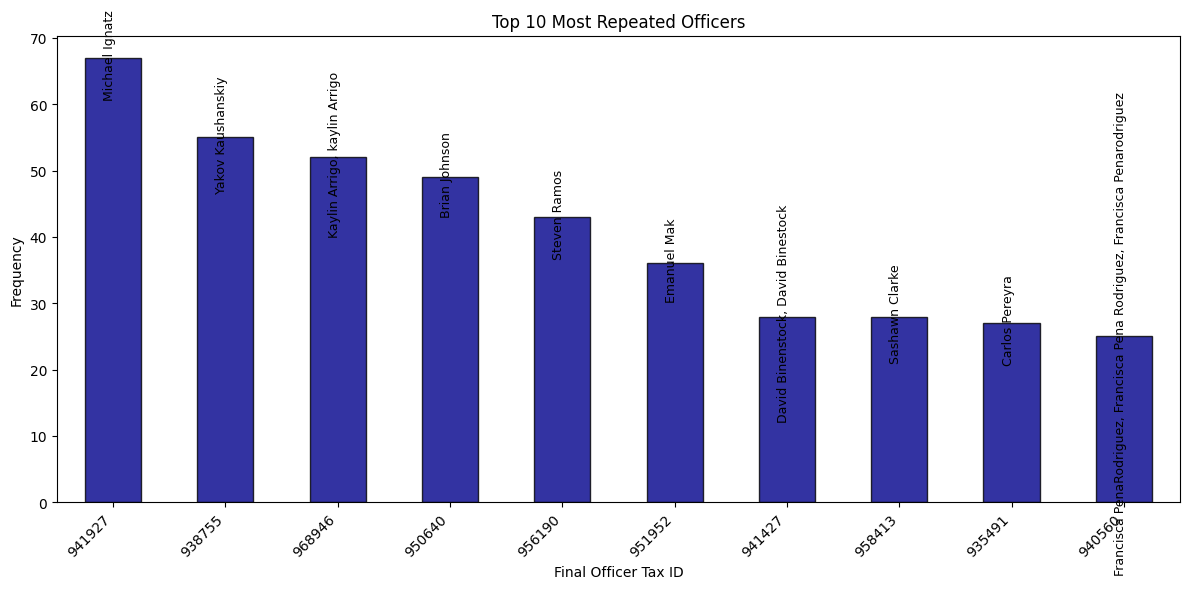

In [ ]:
# Group by 'Final_Officer_Tax_ID' and count repetitions
id_counts = clean_2021.groupby("Final_Officer_Tax_ID").size().sort_values(ascending=False)

# Filter for the top 10 repeated IDs
top_ids = id_counts.head(10)

# Rows for the top IDs and map officer names (First + Last Name) to these IDs
top_ids_df = clean_2021[clean_2021["Final_Officer_Tax_ID"].isin(top_ids.index)]

# Create a new column for Full Officer Name
top_ids_df["Full_Officer_Name"] = (
    top_ids_df["Final_Officer_First_Name"] + " " + top_ids_df["Final_Officer_Last_Name"]
)

# Group by Tax ID and concatenate officer names
officer_names_by_id = top_ids_df.groupby("Final_Officer_Tax_ID")["Full_Officer_Name"].unique()

# Frequency Plot
plt.figure(figsize=(12, 6))
top_ids.plot(kind="bar", color="darkblue", alpha=0.8, edgecolor="black")
plt.title("Top 10 Most Repeated Officers")
plt.xlabel("Final Officer Tax ID")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

# Annotate officer names on the bars
for index, value in enumerate(top_ids):
    officer_names = ", ".join(officer_names_by_id[top_ids.index[index]])
    plt.text(index, value + 0.5, officer_names, fontsize=9, ha="center", rotation=90, wrap=True)

plt.tight_layout()
plt.show()

In [ ]:
# Get top 10 officer IDs
top_ids = clean_2021["Final_Officer_Tax_ID"].value_counts().head(10)

# Filter relevant rows
top_officer_rows = clean_2021[clean_2021["Final_Officer_Tax_ID"].isin(top_ids.index)].copy()

# Create full name column
top_officer_rows["Full_Officer_Name"] = (
    top_officer_rows["Final_Officer_First_Name"] + " " + top_officer_rows["Final_Officer_Last_Name"]
)

# Group by Tax ID and get unique names + citation counts
top_officer_summary = top_officer_rows.groupby("Final_Officer_Tax_ID").agg({
    "Full_Officer_Name": lambda x: ", ".join(set(x)),  # combine unique names
    "Final_Officer_Tax_ID": "count"
}).rename(columns={"Final_Officer_Tax_ID": "Citation_Count"}).reset_index()

# Rename columns for clarity
top_officer_summary = top_officer_summary[["Final_Officer_Tax_ID", "Full_Officer_Name", "Citation_Count"]]
top_officer_summary = top_officer_summary.sort_values("Citation_Count", ascending=False).reset_index(drop=True)

top_officer_summary


,Final_Officer_Tax_ID,Full_Officer_Name,Citation_Count
0,941927,Michael Ignatz,67
1,938755,Yakov Kaushanskiy,55
2,968946,"kaylin Arrigo, Kaylin Arrigo",52
3,950640,Brian Johnson,49
4,956190,Steven Ramos,43
5,951952,Emanuel Mak,36
6,958413,Sashawn Clarke,28
7,941427,"David Binenstock, David Binestock",28
8,935491,Carlos Pereyra,27
9,940560,"Francisca Pena Rodriguez, Francisca Penarodrig...",25


### 10. Total Computer-Generated Citations

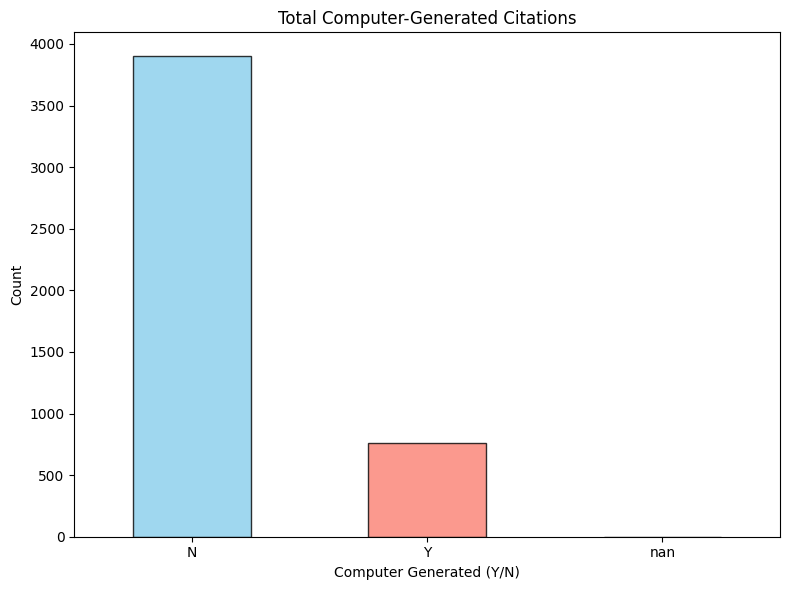

In [ ]:
# clean_2021 computer-generated count
computer_generated_counts = clean_2021["Computer_Generated_YN"].value_counts()

# Plot
plt.figure(figsize=(8, 6))
computer_generated_counts.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black", alpha=0.8)
plt.title("Total Computer-Generated Citations")
plt.xlabel("Computer Generated (Y/N)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
clean_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Ticket_Number                   4663 non-null   float64
 1   Complaintants_First_Name        4663 non-null   object 
 2   Complaintants_Last_Name         4663 non-null   object 
 3   Tax_Registry_Number_Tax_ID      4663 non-null   object 
 4   Agency                          4663 non-null   object 
 5   Confidence_on_PO_Name           4663 non-null   object 
 6   Confidence_on_Officer_Tax_ID    4663 non-null   object 
 7   Alternative_Officer_First_Name  4663 non-null   object 
 8   Alternative_Officer_Last_Name   4663 non-null   object 
 9   Alternative_Officer_Tax_ID      4663 non-null   object 
 10  Verified_Name_w_Tax_ID          4663 non-null   object 
 11  Last_Name_First_Name            4663 non-null   object 
 12  If_Partial_Illegible_ID         46

In [ ]:
# Final Computer-Generated Count
computer_generated_counts = clean_2021["Computer_Generated_YN"].value_counts()
computer_generated_counts

,count
Computer_Generated_YN,
N,3899
Y,763
nan,1


In [ ]:
clean_2021.isnull().sum()

,0
Ticket_Number,0
Complaintants_First_Name,0
Complaintants_Last_Name,0
Tax_Registry_Number_Tax_ID,0
Agency,0
Confidence_on_PO_Name,0
Confidence_on_Officer_Tax_ID,0
Alternative_Officer_First_Name,0
Alternative_Officer_Last_Name,0
Alternative_Officer_Tax_ID,0
